# 🎬 넷플릭스 94개국 데이터를 통한 영화 vs 드라마 선호도 군집화 분석

---

## 1. 분석 배경 및 목표
* **배경**: "아시아 국가들은 드라마를 더 좋아하고, 서구권은 영화를 더 좋아할까?"라는 통념적 가설 검증
* **목표**: 넷플릭스 주간 Top 10 데이터(2021.07 ~ 2022.01, 94개국)를 바탕으로 국가별 콘텐츠(Films vs TV) 선호 유형을 군집화(Clustering)하여 패턴 발굴

---

## 2. 데이터 소개 및 전처리
* **데이터 구조 비교**:
  * `global.csv`: 전 세계 통합 순위 및 시청 시간 (Global Top 10)
  * `countries.csv`: 94개국별 개별 Top 10 순위
* **인코딩 문제 해결**: `cp1252`와 `utf-8-sig` 혼재 문제 해결을 위한 전처리 수행
* **데이터 병합**: `week` + `show_title` + `season_title` 기준 병합
  * *매칭률 63.5%*: 국가별 Top 10에만 오르고 글로벌 Top 10에는 진입하지 못한 로컬 콘텐츠 차이로 발생

---

## 3. 분석 함정 발견 (Key Finding)
* **초기 접근법**: '국가별 Films 개수 vs TV Show 개수' 비율 비교
* **구조적 함정 발견**: 넷플릭스 주간 차트 시스템 특성상 모든 국가가 항상 **Films 290개 / TV 290개 (정확히 50:50)**로 고정되어 있음
* **시사점**: 단순 집계 수치를 그대로 사용할 수 없으며, 실제 선호도를 반영할 새로운 피처 엔지니어링 필요성 확인

---

## 4. 대체 지표 설계 (Feature Engineering)
구조적 함정을 우회하고 실제 차트 체류 및 몰입도를 측정하기 위한 지표 개발:

1. **`avg_cum_weeks`**: 카테고리별 차트 내 평균 누적 체류 주차 (얼마나 오래 머무는가)
2. **`unique_titles`**: 차트에 진입한 순수 작품 수 (작품 다양성)
3. **`tv_stickiness_ratio`**: TV 카테고리가 Films에 비해 얼마나 차트에 오래 머무는지 나타내는 상대적 몰입도 지표

---

## 5. 군집화 방법 및 결과 (K-Means)
* **전처리**: `StandardScaler`를 이용한 피처 표준화
* **알고리즘**: K-Means Clustering ($k=3$)

| 군집 (Cluster) | 평균 TV 몰입도 (`tv_stickiness_ratio`) | 특징 | 대표 국가 |
| :--- | :---: | :--- | :--- |
| **Cluster 0** | **3.47** | **드라마 초고몰입형** (TV 차트 장기 집권) | 일본, 태국, 베트남, 중남미 주요국 |
| **Cluster 1** | **1.83** | **중립 / 밸런스형** | 동유럽, 중동 일부 국가 |
| **Cluster 2** | **1.76** | **상대적 영화 선호형** (Films 교체율 높음) | 한국, 대만, 인도, 서유럽, 북미, 오세아니아 |

---

## 6. 시각화 (Choropleth Map)
* **Plotly Choropleth Map**을 활용하여 94개국별 군집 분포를 세계지도 상에 시각화
* 한눈에 대륙별/지역별 콘텐츠 소비 패턴의 유사성과 차이점을 직관적으로 전달

---

## 7. 핵심 인사이트
* 💡 **반전 포인트 (통념 검증)**:
  * "아시아 = 드라마파"라는 가설은 **절반만 사실**
  * 일본·태국·베트남은 예상대로 **드라마 초고몰입형**
  * 반면 **한국·대만·인도는 북미/서유럽과 함께 영화 선호형 군집**에 속함
* 🌍 **글로벌 패턴 Summary**:
  * **중남미 + 동남아 일부/일본**: 드라마 장기 시청 및 높은 몰입도
  * **북미 + 서유럽 + 한국/대만/인도**: 다양한 영화 및 신규 콘텐츠 빠른 소비

---

## 8. 분석의 한계점 및 향후 방향
* ⏳ **기간 한정**: 약 6개월 데이터로 계절성(Seasonality) 미반영
* 📊 **지표 제한**: 국가별 데이터에는 시청시간(Hours Viewed)이 없어 글로벌 매칭 작품(63.5%)에 대해서만 보정 가능
* 🔍 **k값 검증 필요**: Elbow Method 및 Silhouette Score를 통한 군집 수($k$) 최적화 검증 단계 추가 필요

# 데이터 합치기

In [1]:
"""
넷플릭스 주간 Top10 데이터 - global / countries 파일 병합 및 컬럼 확인

목적:
1. 두 파일을 각각 읽어서 컬럼 구조를 확인
2. countries.csv(국가별 순위)에 global.csv(주간 시청시간)를 붙여서
   country + week + show_title 기준으로 결합한 통합 데이터셋을 만듦
"""

import pandas as pd

# ---------------------------------------------------------
# 1. 파일 불러오기
#    - 두 파일 모두 특수문자(외국어 제목 등) 때문에 utf-8로 읽으면 에러가 남
#    - cp1252 인코딩으로 읽으면 정상적으로 파싱됨
# ---------------------------------------------------------
global_path = r"D:\ai-campus-project\ABA_1st_proj_수정\[엔터] Netflix Top 10 Weekly Dataset\all-weeks-global.csv"     # 실제 파일 경로로 수정
countries_path = r"D:\ai-campus-project\ABA_1st_proj_수정\[엔터] Netflix Top 10 Weekly Dataset\all-weeks-countries.csv"  # 실제 파일 경로로 수정

df_global = pd.read_csv(global_path, encoding="utf-8-sig")  # global은 BOM 포함 UTF-8
df_countries = pd.read_csv(countries_path, encoding="cp1252")  # countries는 cp1252

# ---------------------------------------------------------
# 2. 각 파일 컬럼/형태 확인
# ---------------------------------------------------------
print("=" * 60)
print("[global.csv] shape:", df_global.shape)
print("[global.csv] columns:", df_global.columns.tolist())
print(df_global.head(3))

print("=" * 60)
print("[countries.csv] shape:", df_countries.shape)
print("[countries.csv] columns:", df_countries.columns.tolist())
print(df_countries.head(3))

# ---------------------------------------------------------
# 3. 두 파일 구조 비교
#    - global: week, category, weekly_rank, show_title, season_title,
#              weekly_hours_viewed, cumulative_weeks_in_top_10
#    - countries: country_name, country_iso2, week, category, weekly_rank,
#                 show_title, season_title, cumulative_weeks_in_top_10
#    - 공통 컬럼: week, show_title, season_title
#      (category 값 표기가 다름: global은 "Films (English)" 등 4종,
#       countries는 "Films"/"TV" 2종 이라 category는 조인 키로 안 씀)
# ---------------------------------------------------------
common_cols = set(df_global.columns) & set(df_countries.columns)
print("=" * 60)
print("공통 컬럼:", common_cols)
print("global에만 있는 컬럼:", set(df_global.columns) - common_cols)
print("countries에만 있는 컬럼:", set(df_countries.columns) - common_cols)

# ---------------------------------------------------------
# 4. 결합 (merge)
#    countries 데이터(국가별 순위)에 global 데이터의 weekly_hours_viewed를
#    같은 주(week) + 같은 작품(show_title, season_title) 기준으로 붙임
#    -> 국가별 순위 데이터에 "이 작품이 그 주에 전세계적으로 얼마나 시청됐는지" 추가
# ---------------------------------------------------------
df_merged = df_countries.merge(
    df_global[["week", "show_title", "season_title", "weekly_hours_viewed"]],
    on=["week", "show_title", "season_title"],
    how="left",
)

print("=" * 60)
print("[병합 결과] shape:", df_merged.shape)
print("[병합 결과] columns:", df_merged.columns.tolist())
print(df_merged.head(5))

# weekly_hours_viewed가 매칭 안 된 행 비율 확인
# (제목 표기가 미세하게 다르거나, 시즌 정보 차이로 매칭이 안 될 수 있음)
match_rate = df_merged["weekly_hours_viewed"].notna().mean()
print(f"\nglobal 시청시간 매칭률: {match_rate:.1%}")

# ---------------------------------------------------------
# 5. 결과 저장 (선택)
# ---------------------------------------------------------
df_merged.to_csv("merged_countries_with_hours.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: merged_countries_with_hours.csv")

[global.csv] shape: (1160, 7)
[global.csv] columns: ['week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'cumulative_weeks_in_top_10']
         week         category  weekly_rank      show_title season_title  \
0  2022-01-16  Films (English)            1          Brazen          NaN   
1  2022-01-16  Films (English)            2   Don't Look Up          NaN   
2  2022-01-16  Films (English)            3  Mother/Android          NaN   

   weekly_hours_viewed  cumulative_weeks_in_top_10  
0             45340000                           1  
1             28390000                           4  
2             23170000                           2  
[countries.csv] shape: (54520, 8)
[countries.csv] columns: ['country_name', 'country_iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10']
  country_name country_iso2        week category  weekly_rank  \
0    Argentina           AR  2022-01-16    Films            

# 컬럼표시

In [10]:
print("=" * 60)
print(f"[전체 컬럼 목록 (총 {len(df_merged.columns)}개)]")
for idx, col in enumerate(df_merged.columns, 1):
    print(f"{idx:2d}. {col}")

[전체 컬럼 목록 (총 9개)]
 1. country_name
 2. country_iso2
 3. week
 4. category
 5. weekly_rank
 6. show_title
 7. season_title
 8. cumulative_weeks_in_top_10
 9. weekly_hours_viewed


# 기간 확인

In [11]:
# 전체 주차 목록 (오름차순 정렬)
all_weeks = sorted(df_merged['week'].unique())

print("=" * 60)
print(f"[전체 주차 목록 (총 {len(all_weeks)}개 주)]")
print(all_weeks)

[전체 주차 목록 (총 29개 주)]
['2021-07-04', '2021-07-11', '2021-07-18', '2021-07-25', '2021-08-01', '2021-08-08', '2021-08-15', '2021-08-22', '2021-08-29', '2021-09-05', '2021-09-12', '2021-09-19', '2021-09-26', '2021-10-03', '2021-10-10', '2021-10-17', '2021-10-24', '2021-10-31', '2021-11-07', '2021-11-14', '2021-11-21', '2021-11-28', '2021-12-05', '2021-12-12', '2021-12-19', '2021-12-26', '2022-01-02', '2022-01-09', '2022-01-16']


- 2021-07-04부터 2022-01-16 있음을 확인

# 국가 개수 및 전체 국가 목록 확인

In [14]:
# ---------------------------------------------------------
# 7. 포함된 국가 정보 확인 (개수 및 목록)
# ---------------------------------------------------------
# 중복을 제거한 국가 목록 추출 (알파벳/가나다 순 정렬)
unique_countries = sorted(df_merged['country_name'].dropna().unique())
total_country_count = len(unique_countries)

print("=" * 60)
print(f"포함된 총 국가 수: {total_country_count}개국")
print("=" * 60)

# 전체 국가 목록을 번호와 함께 세로로 출력
print("[전체 국가 목록]")
for idx, country in enumerate(unique_countries, 1):
    print(f"{idx:2d}. {country}")

포함된 총 국가 수: 94개국
[전체 국가 목록]
 1. Argentina
 2. Australia
 3. Austria
 4. Bahamas
 5. Bahrain
 6. Bangladesh
 7. Belgium
 8. Bolivia
 9. Brazil
10. Bulgaria
11. Canada
12. Chile
13. Colombia
14. Costa Rica
15. Croatia
16. Cyprus
17. Czech Republic
18. Denmark
19. Dominican Republic
20. Ecuador
21. Egypt
22. El Salvador
23. Estonia
24. Finland
25. France
26. Germany
27. Greece
28. Guadeloupe
29. Guatemala
30. Honduras
31. Hong Kong
32. Hungary
33. Iceland
34. India
35. Indonesia
36. Ireland
37. Israel
38. Italy
39. Jamaica
40. Japan
41. Jordan
42. Kenya
43. Kuwait
44. Latvia
45. Lebanon
46. Lithuania
47. Luxembourg
48. Malaysia
49. Maldives
50. Malta
51. Martinique
52. Mauritius
53. Mexico
54. Morocco
55. Netherlands
56. New Caledonia
57. New Zealand
58. Nicaragua
59. Nigeria
60. Norway
61. Oman
62. Pakistan
63. Panama
64. Paraguay
65. Peru
66. Philippines
67. Poland
68. Portugal
69. Qatar
70. Romania
71. Russia
72. Réunion
73. Saudi Arabia
74. Serbia
75. Singapore
76. Slovakia
77. Sloven

= 총 국가 94개국이 있음을 확인

# 영화파 vs 드라마파 국가 군집화

In [2]:
"""
'영화파 vs 드라마파' 국가 군집화

핵심 함정 주의:
- countries.csv는 국가마다 Films 290개, TV 290개로 항상 정확히 50:50임
  (Top10이 카테고리별로 고정 10자리 x 29주 이기 때문)
  -> 단순 "Films 개수 vs TV 개수" 비율로는 국가 차이가 전혀 안 드러남

- 대신 아래 두 지표로 "얼마나 몰입해서 보는지"를 잡음
  1) avg_cum_weeks : 카테고리별 cumulative_weeks_in_top_10 평균
     -> 높을수록 같은 작품이 오래 순위권에 머묾 (몰입/충성도 높음)
  2) unique_titles  : 카테고리별 등장한 고유 작품 수
     -> 낮을수록 소수 작품이 순위를 오래 독점함 (unique_titles와 avg_cum_weeks는 반비례 관계)
"""

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. 데이터 로드
# ---------------------------------------------------------
countries_path = r"D:\ai-campus-project\ABA_1st_proj_수정\[엔터] Netflix Top 10 Weekly Dataset\all-weeks-countries.csv"  # 실제 파일 경로로 수정
df = pd.read_csv(countries_path, encoding="cp1252")

# ---------------------------------------------------------
# 2. 국가 x 카테고리별 피처 계산
# ---------------------------------------------------------
feat = df.groupby(["country_name", "category"]).agg(
    avg_cum_weeks=("cumulative_weeks_in_top_10", "mean"),
    unique_titles=("show_title", "nunique"),
).unstack()  # 컬럼이 (avg_cum_weeks, Films), (avg_cum_weeks, TV) 형태의 멀티인덱스가 됨

feat.columns = ["_".join(col) for col in feat.columns]
feat = feat.reset_index()

# ---------------------------------------------------------
# 3. '드라마 몰입 지수' 만들기
#    TV가 Films보다 얼마나 더 오래 순위권에 머무는지 비율로 표현
#    1보다 크면 TV(드라마) 쪽이 더 몰입도 높은 국가
# ---------------------------------------------------------
feat["tv_stickiness_ratio"] = feat["avg_cum_weeks_TV"] / feat["avg_cum_weeks_Films"]
feat["tv_diversity_ratio"] = feat["unique_titles_TV"] / feat["unique_titles_Films"]
# diversity_ratio가 낮을수록(작품 종류가 적을수록) 소수 TV작품 몰입형

print("=" * 60)
print("피처 미리보기")
print(feat.sort_values("tv_stickiness_ratio", ascending=False).head(10))

# ---------------------------------------------------------
# 4. K-Means 군집화
#    피처: avg_cum_weeks_Films, avg_cum_weeks_TV, unique_titles_Films, unique_titles_TV
#    스케일이 다른 피처들이라 표준화(StandardScaler) 후 군집화
# ---------------------------------------------------------
cluster_features = [
    "avg_cum_weeks_Films",
    "avg_cum_weeks_TV",
    "unique_titles_Films",
    "unique_titles_TV",
]
X = feat[cluster_features].values
X_scaled = StandardScaler().fit_transform(X)

k = 3  # 군집 수. 3~4 사이로 바꿔가며 결과 비교해보는 걸 추천
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
feat["cluster"] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# 5. 군집별 특징 확인
#    각 군집의 tv_stickiness_ratio 평균을 보고
#    "드라마파 / 영화파 / 중립" 같은 이름을 붙여볼 수 있음
# ---------------------------------------------------------
print("=" * 60)
print("군집별 평균 특성")
cluster_summary = feat.groupby("cluster")[cluster_features + ["tv_stickiness_ratio"]].mean()
print(cluster_summary)

print("=" * 60)
print("군집별 국가 목록 (tv_stickiness_ratio 높은 순)")
for c in sorted(feat["cluster"].unique()):
    sub = feat[feat["cluster"] == c].sort_values("tv_stickiness_ratio", ascending=False)
    print(f"\n--- Cluster {c} (국가 수: {len(sub)}, 평균 TV몰입지수: {sub['tv_stickiness_ratio'].mean():.2f}) ---")
    print(sub["country_name"].tolist())

# ---------------------------------------------------------
# 6. 결과 저장
# ---------------------------------------------------------
feat.to_csv("country_clusters.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: country_clusters.csv")

피처 미리보기
   country_name  avg_cum_weeks_Films  avg_cum_weeks_TV  unique_titles_Films  \
19      Ecuador             1.693103          7.234483                  169   
57    Nicaragua             1.662069          7.041379                  171   
29     Honduras             1.682759          7.058621                  164   
60         Oman             1.786207          7.282759                  154   
21  El Salvador             1.703448          6.744828                  168   
64         Peru             1.648276          6.410345                  170   
28    Guatemala             1.803448          7.006897                  158   
13   Costa Rica             1.731034          6.706897                  167   
63     Paraguay             1.634483          6.100000                  166   
12     Colombia             1.920690          6.934483                  150   

    unique_titles_TV  tv_stickiness_ratio  tv_diversity_ratio  
19                45             4.272912            0.266

# 국가 군집 결과를 세계지도에 시각화

In [3]:
"""
'영화파 vs 드라마파' 국가 군집 결과를 세계지도에 시각화

사전 설치 필요 (터미널에서 한 번만 실행):
    pip install plotly

이 스크립트는 02_country_clustering.py 결과로 저장된
country_clusters.csv를 불러와서 지도에 색칠함.
(02번 스크립트를 먼저 실행해서 country_clusters.csv가 있어야 함)
"""

import pandas as pd
import plotly.express as px

# ---------------------------------------------------------
# 1. 군집 결과 불러오기
# ---------------------------------------------------------
df = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")

# ---------------------------------------------------------
# 2. 군집 번호를 보기 좋은 이름으로 바꾸기
#    02번 스크립트 실행 결과를 참고해서 직접 라벨을 붙여줌
#    (K-Means는 매번 군집 번호가 바뀔 수 있어서, 실행할 때마다
#     cluster_summary를 확인하고 아래 매핑을 맞게 수정해야 함)
# ---------------------------------------------------------
cluster_summary = df.groupby("cluster")["tv_stickiness_ratio"].mean().sort_values(ascending=False)
print("군집별 평균 TV 몰입지수 (높은 순):")
print(cluster_summary)

# tv_stickiness_ratio가 가장 높은 군집 = 드라마파, 가장 낮은 군집 = 영화파로 자동 라벨링
ordered_clusters = cluster_summary.index.tolist()
label_map = {}
if len(ordered_clusters) == 3:
    label_map = {
        ordered_clusters[0]: "드라마 몰입형",
        ordered_clusters[1]: "중립형",
        ordered_clusters[2]: "영화 선호형",
    }
else:
    # 군집 수가 3이 아니면 번호를 그대로 문자열 라벨로 사용
    label_map = {c: f"Cluster {c}" for c in ordered_clusters}

df["cluster_label"] = df["cluster"].map(label_map)

# ---------------------------------------------------------
# 3. 세계지도 choropleth 그리기
#    locationmode="country names"를 쓰면 country_name 컬럼의
#    영문 국가명을 그대로 지도 매칭에 사용할 수 있음
#    (단, 일부 국가명이 plotly 내부 지도 데이터와 다르게 표기되어
#     매칭이 안 될 수 있음 -> 지도에서 회색으로 나오면 이름 불일치 의심)
# ---------------------------------------------------------
fig = px.choropleth(
    df,
    locations="country_name",
    locationmode="country names",
    color="cluster_label",
    hover_name="country_name",
    hover_data={
        "tv_stickiness_ratio": ":.2f",
        "cluster_label": False,
    },
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="넷플릭스 국가별 시청 성향 군집: 영화파 vs 드라마파",
)

fig.update_layout(
    legend_title_text="군집",
    margin=dict(l=0, r=0, t=50, b=0),
)

# ---------------------------------------------------------
# 4. 결과 확인 및 저장
#    HTML 저장을 먼저 해서, 노트북에서 show()가 실패해도
#    (nbformat 미설치 등) 파일은 항상 남도록 함
# ---------------------------------------------------------
fig.write_html("country_cluster_map.html")  # 발표자료에 첨부 가능한 HTML로 저장
print("저장 완료: country_cluster_map.html (더블클릭해서 브라우저로 열면 됨)")

try:
    fig.show()  # 노트북/브라우저에서 인터랙티브 지도 열림 (nbformat 필요할 수 있음)
except Exception as e:
    print(f"\n(참고) 인터랙티브 미리보기는 건너뜀: {e}")
    print("country_cluster_map.html 파일을 열어서 확인해주세요.")

# 지도 매칭이 안 된 국가(회색으로 표시되는 국가) 확인하고 싶으면
# 아래처럼 plotly 내장 국가 목록과 직접 비교해볼 수 있음:
# import plotly.data as pdata  # 참고용, 필수 아님

군집별 평균 TV 몰입지수 (높은 순):
cluster
0    3.470353
1    1.832230
2    1.762767
Name: tv_stickiness_ratio, dtype: float64


C:\Users\seokho\AppData\Local\Temp\ipykernel_30388\2120046913.py:52: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


저장 완료: country_cluster_map.html (더블클릭해서 브라우저로 열면 됨)

(참고) 인터랙티브 미리보기는 건너뜀: Mime type rendering requires nbformat>=4.2.0 but it is not installed
country_cluster_map.html 파일을 열어서 확인해주세요.


# 저장된 파일 위치 확인

In [4]:
import os
print(os.getcwd())
print(os.path.exists("country_cluster_map.html"))
print(os.path.abspath("country_cluster_map.html"))

d:\ai-campus-project
True
d:\ai-campus-project\country_cluster_map.html


- 군집 세계화 지도
  https://starlit-bubblegum-854a1c.netlify.app/

### 비지니스 모델 확대
- 예시) 영화 제작을 할 건데 어느 나라들을 타겟으로 하는게 나을까?

# 국가별 시청 성향 분석(드라마/영화)

In [5]:
"""
'영화 타겟 국가' 우선순위 리스트 만들기
= 군집(영화 선호 성향) + 시장 규모(시청시간) 교차

전제 조건: 아래 두 스크립트를 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

로직:
1) 군집 결과에서 '영화 선호형' 국가군을 골라냄
   (tv_stickiness_ratio 평균이 가장 낮은 군집 = TV보다 영화가 상대적으로
    강세인 국가군 -> 영화 제작사 입장에서 성향상 맞는 시장)
2) 시장 규모는 '이 나라 Films Top10에 든 작품들의 weekly_hours_viewed 합'으로 정의
   (01번에서 만든 병합 데이터 사용. global Top10과 매칭 안 된 행은 제외되므로
    실제보다 시장 규모가 과소 추정될 수 있음 - 한계점으로 발표 때 언급 필요)
3) 두 조건을 교차해서 "성향도 맞고 시장도 큰" 국가부터 정렬
"""

import pandas as pd

# ---------------------------------------------------------
# 1. 데이터 로드
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

# ---------------------------------------------------------
# 2. 군집에 '성향 라벨' 붙이기
#    tv_stickiness_ratio 평균이 가장 낮은 군집 = 영화 선호형
#    가장 높은 군집 = 드라마 몰입형, 중간 = 중립형
# ---------------------------------------------------------
cluster_avg = clusters.groupby("cluster")["tv_stickiness_ratio"].mean().sort_values()
ordered = cluster_avg.index.tolist()  # 오름차순: [영화선호형, 중립형, 드라마몰입형]

if len(ordered) == 3:
    tendency_map = {
        ordered[0]: "영화 선호형",
        ordered[1]: "중립형",
        ordered[2]: "드라마 몰입형",
    }
else:
    tendency_map = {c: f"Cluster {c}" for c in ordered}

clusters["tendency"] = clusters["cluster"].map(tendency_map)

print("=" * 60)
print("군집별 평균 TV 몰입지수 및 성향 라벨")
print(cluster_avg)
print(tendency_map)

# ---------------------------------------------------------
# 3. 국가별 '영화 시장 규모' 계산
#    Films 카테고리에서 이 나라 Top10에 든 작품들의 weekly_hours_viewed 합
#    (global Top10과 매칭 안 된 행은 NaN -> sum에서 자동 제외됨)
# ---------------------------------------------------------
film_rows = merged[merged["category"] == "Films"]
market_size = (
    film_rows.groupby("country_name")["weekly_hours_viewed"]
    .sum()
    .reset_index()
    .rename(columns={"weekly_hours_viewed": "film_market_size_hours"})
)

# 매칭된 행이 아예 없는 나라는 시장 규모 0으로 처리(참고용, 실제로는 결측일 뿐 0이 아닐 수 있음)
market_size["film_market_size_hours"] = market_size["film_market_size_hours"].fillna(0)

# ---------------------------------------------------------
# 4. 군집(성향) + 시장 규모 병합
# ---------------------------------------------------------
result = clusters.merge(market_size, on="country_name", how="left")
result["film_market_size_hours"] = result["film_market_size_hours"].fillna(0)

# ---------------------------------------------------------
# 5. 타겟 우선순위 매기기
#    1차 타겟: 영화 선호형 + 시장 규모 상위
#    2차 타겟: 중립형 + 시장 규모 상위
#    (드라마 몰입형은 이번 '영화 제작' 목적에서는 제외)
# ---------------------------------------------------------
result["target_tier"] = "제외"
result.loc[result["tendency"] == "영화 선호형", "target_tier"] = "1차 타겟"
result.loc[result["tendency"] == "중립형", "target_tier"] = "2차 타겟"

target_list = result[result["target_tier"] != "제외"].copy()
target_list = target_list.sort_values(
    by=["target_tier", "film_market_size_hours"], ascending=[True, False]
)

print("=" * 60)
print(f"영화 제작 타겟 국가 우선순위 (전체 {len(target_list)}개국)")
cols_to_show = ["country_name", "target_tier", "tendency", "tv_stickiness_ratio", "film_market_size_hours"]
pd.set_option("display.max_rows", None)  # 출력 시 행 개수 제한 해제
print(target_list[cols_to_show].to_string(index=False))

# ---------------------------------------------------------
# 6. 결과 저장
# ---------------------------------------------------------
target_list[cols_to_show].to_csv("target_countries.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: target_countries.csv")

군집별 평균 TV 몰입지수 및 성향 라벨
cluster
2    1.762767
1    1.832230
0    3.470353
Name: tv_stickiness_ratio, dtype: float64
{2: '영화 선호형', 1: '중립형', 0: '드라마 몰입형'}
영화 제작 타겟 국가 우선순위 (전체 71개국)
        country_name target_tier tendency  tv_stickiness_ratio  film_market_size_hours
            Portugal       1차 타겟   영화 선호형             2.115028            4506270000.0
             Croatia       1차 타겟   영화 선호형             1.448553            4402150000.0
             Hungary       1차 타겟   영화 선호형             1.771565            4382880000.0
            Slovakia       1차 타겟   영화 선호형             1.641860            4292750000.0
              Serbia       1차 타겟   영화 선호형             1.727891            4249410000.0
             Ukraine       1차 타겟   영화 선호형             1.751061            4168220000.0
              Russia       1차 타겟   영화 선호형             1.931078            4166960000.0
      Czech Republic       1차 타겟   영화 선호형             1.699088            4128750000.0
           Lithuania       1차 타겟   영화

# 지도 클릭 -> 상세정보 패널 구조 형성

In [6]:
"""
군집화 + 영화/TV 선호도 결과를 인터랙티브 웹사이트(HTML)로 만들기

전제 조건: 아래 스크립트들을 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

만들어지는 결과:
  entertainment_country_map.html
  -> 더블클릭하면 브라우저에서 열리는 인터랙티브 세계지도.
     국가를 클릭하면 영화%/TV% 비율과 시장 규모가 오른쪽 패널에 표시됨.
     (지도 라이브러리를 CDN에서 불러오므로 열 때 인터넷 연결 필요)
"""

import json
import pandas as pd

# ---------------------------------------------------------
# 1. 데이터 로드 및 성향 라벨링 (02, 04번과 동일 로직)
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

cluster_avg = clusters.groupby("cluster")["tv_stickiness_ratio"].mean().sort_values()
ordered = cluster_avg.index.tolist()
tendency_map = {
    ordered[0]: "영화 선호형",
    ordered[1]: "중립형",
    ordered[2]: "드라마 몰입형",
}
clusters["tendency"] = clusters["cluster"].map(tendency_map)

# ---------------------------------------------------------
# 2. 영화%/TV% 계산
#    tv_stickiness_ratio = TV가 Films보다 몇 배 오래 순위권에 머무는지
#    이를 0~100% 비율로 정규화
# ---------------------------------------------------------
clusters["tv_pct"] = (
    clusters["tv_stickiness_ratio"] / (clusters["tv_stickiness_ratio"] + 1) * 100
).round(1)
clusters["film_pct"] = (100 - clusters["tv_pct"]).round(1)

# ---------------------------------------------------------
# 3. 영화 시장 규모(누적 시청시간) 계산 - 04번과 동일
# ---------------------------------------------------------
film_rows = merged[merged["category"] == "Films"]
market = (
    film_rows.groupby("country_name")["weekly_hours_viewed"]
    .sum()
    .reset_index()
    .rename(columns={"weekly_hours_viewed": "film_market_hours"})
)

result = clusters.merge(market, on="country_name", how="left")
result["film_market_hours"] = result["film_market_hours"].fillna(0)

# ---------------------------------------------------------
# 4. 웹사이트에 넣을 JSON 데이터 만들기
# ---------------------------------------------------------
site_data = result[["country_name", "tendency", "film_pct", "tv_pct", "film_market_hours"]]
records = site_data.to_dict(orient="records")
print(f"{len(records)}개국 데이터 준비 완료")

# ---------------------------------------------------------
# 5. HTML 템플릿에 데이터 삽입 후 파일 저장
# ---------------------------------------------------------
html_template = """<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>넷플릭스 국가별 시청 성향 지도</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/plotly.js/2.27.0/plotly.min.js"></script>
<style>
  :root {
    --bg: #0b0d12;
    --panel: #14171f;
    --panel-border: #232733;
    --text: #e8eaf0;
    --muted: #8b90a0;
    --film: #e0575b;
    --tv: #4fa3d1;
    --accent: #f2c14e;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    background: var(--bg);
    color: var(--text);
    font-family: -apple-system, "Pretendard", "Apple SD Gothic Neo", "Malgun Gothic", sans-serif;
  }
  header {
    padding: 28px 32px 18px;
    border-bottom: 1px solid var(--panel-border);
  }
  header h1 {
    margin: 0 0 6px;
    font-size: 22px;
    font-weight: 700;
    letter-spacing: -0.01em;
  }
  header p {
    margin: 0;
    color: var(--muted);
    font-size: 14px;
  }
  .layout {
    display: grid;
    grid-template-columns: 1fr 340px;
    gap: 0;
    min-height: calc(100vh - 92px);
  }
  @media (max-width: 860px) {
    .layout { grid-template-columns: 1fr; }
  }
  .map-area {
    padding: 12px;
    position: relative;
  }
  #map {
    width: 100%;
    height: 640px;
  }
  .legend {
    display: flex;
    gap: 18px;
    padding: 0 20px 8px;
    font-size: 12px;
    color: var(--muted);
    flex-wrap: wrap;
  }
  .legend span { display: inline-flex; align-items: center; gap: 6px; }
  .dot { width: 9px; height: 9px; border-radius: 2px; display: inline-block; }
  .panel {
    border-left: 1px solid var(--panel-border);
    padding: 24px;
    background: var(--panel);
  }
  .panel-empty {
    color: var(--muted);
    font-size: 14px;
    line-height: 1.7;
    margin-top: 60px;
    text-align: center;
  }
  .panel-empty .big { font-size: 32px; display: block; margin-bottom: 10px; }
  .country-name {
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 2px;
  }
  .tendency-badge {
    display: inline-block;
    font-size: 12px;
    padding: 3px 9px;
    border-radius: 999px;
    margin-bottom: 20px;
    font-weight: 600;
  }
  .badge-film { background: rgba(224,87,91,0.18); color: var(--film); }
  .badge-tv { background: rgba(79,163,209,0.18); color: var(--tv); }
  .badge-neutral { background: rgba(242,193,78,0.18); color: var(--accent); }

  .bar-row { margin-bottom: 8px; }
  .bar-label {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    margin-bottom: 5px;
  }
  .bar-track {
    height: 10px;
    border-radius: 5px;
    background: #232733;
    overflow: hidden;
    display: flex;
  }
  .bar-fill-film { background: var(--film); height: 100%; }
  .bar-fill-tv { background: var(--tv); height: 100%; }

  .stat-block {
    margin-top: 24px;
    padding-top: 18px;
    border-top: 1px solid var(--panel-border);
  }
  .stat-row {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    padding: 7px 0;
    color: var(--muted);
  }
  .stat-row b { color: var(--text); font-weight: 600; }

  .note {
    margin-top: 22px;
    font-size: 11.5px;
    color: var(--muted);
    line-height: 1.6;
    padding-top: 16px;
    border-top: 1px solid var(--panel-border);
  }
</style>
</head>
<body>

<header>
  <h1>넷플릭스 국가별 영화 vs TV 시청 성향</h1>
  <p>국가를 클릭하면 영화·TV 선호 비율과 시장 규모를 확인할 수 있습니다 (2021.07 ~ 2022.01, 94개국 기준)</p>
</header>

<div class="legend">
  <span><span class="dot" style="background:var(--film)"></span>영화 선호형</span>
  <span><span class="dot" style="background:var(--accent)"></span>중립형</span>
  <span><span class="dot" style="background:var(--tv)"></span>드라마 몰입형</span>
</div>

<div class="layout">
  <div class="map-area">
    <div id="map"></div>
  </div>
  <div class="panel" id="panel">
    <div class="panel-empty">
      <span class="big">🌍</span>
      지도에서 국가를 클릭해보세요
    </div>
  </div>
</div>

<script>
const DATA = __COUNTRY_DATA_JSON__;

const dataByName = {};
DATA.forEach(d => { dataByName[d.country_name] = d; });

const tendencyColor = {
  "영화 선호형": "#e0575b",
  "중립형": "#f2c14e",
  "드라마 몰입형": "#4fa3d1"
};
const tendencyOrder = ["영화 선호형", "중립형", "드라마 몰입형"];

const trace = {
  type: "choropleth",
  locationmode: "country names",
  locations: DATA.map(d => d.country_name),
  z: DATA.map(d => tendencyOrder.indexOf(d.tendency)),
  text: DATA.map(d => d.country_name),
  hoverinfo: "text",
  colorscale: [
    [0, "#e0575b"],
    [0.5, "#f2c14e"],
    [1, "#4fa3d1"]
  ],
  showscale: false,
  marker: { line: { color: "#0b0d12", width: 0.6 } }
};

const layout = {
  geo: {
    projection: { type: "natural earth" },
    showframe: false,
    showcoastlines: false,
    bgcolor: "rgba(0,0,0,0)",
    landcolor: "#1c202b",
    showcountries: true,
    countrycolor: "#0b0d12"
  },
  paper_bgcolor: "rgba(0,0,0,0)",
  margin: { l: 0, r: 0, t: 0, b: 0 },
  font: { color: "#e8eaf0" }
};

Plotly.newPlot("map", [trace], layout, { displayModeBar: false, responsive: true });

document.getElementById("map").on("plotly_click", function(evt) {
  const name = evt.points[0].text;
  const d = dataByName[name];
  if (d) renderPanel(d);
});

function badgeClass(tendency) {
  if (tendency === "영화 선호형") return "badge-film";
  if (tendency === "드라마 몰입형") return "badge-tv";
  return "badge-neutral";
}

function renderPanel(d) {
  const panel = document.getElementById("panel");
  const marketB = (d.film_market_hours / 1e9).toFixed(1);
  panel.innerHTML = `
    <div class="country-name">${d.country_name}</div>
    <div class="tendency-badge ${badgeClass(d.tendency)}">${d.tendency}</div>

    <div class="bar-row">
      <div class="bar-label"><span>🎬 영화</span><span>${d.film_pct}%</span></div>
      <div class="bar-track">
        <div class="bar-fill-film" style="width:${d.film_pct}%"></div>
        <div class="bar-fill-tv" style="width:${d.tv_pct}%"></div>
      </div>
    </div>
    <div class="bar-row">
      <div class="bar-label"><span>📺 TV</span><span>${d.tv_pct}%</span></div>
    </div>

    <div class="stat-block">
      <div class="stat-row"><span>영화 시장 규모(누적 시청시간)</span><b>${marketB}B 시간</b></div>
      <div class="stat-row"><span>분류 기준</span><b>TV 몰입지수 기반 군집</b></div>
    </div>

    <div class="note">
      * 영화%/TV%는 카테고리별 cumulative_weeks_in_top_10(순위권 체류기간) 비율로 계산한 상대적 성향이며, 실제 총 시청량 비율과는 다를 수 있습니다.<br>
      * 영화 시장 규모는 이 국가 Films Top10에 오른 작품들의 글로벌 주간 시청시간 합산치입니다.
    </div>
  `;
}
</script>

</body>
</html>
"""

html_output = html_template.replace("__COUNTRY_DATA_JSON__", json.dumps(records, ensure_ascii=False))

output_path = "entertainment_country_map.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_output)

print(f"\uc800장 완료: {output_path}")
print("만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.")

94개국 데이터 준비 완료
저장 완료: entertainment_country_map.html
만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.


# 지도 개선
- 다른 국가들과 비교한 상대적 순위(백분위)로 바꿔서 자연스럽게 50이 기준이 되도록 설정
- 누적 시청시간 -> 평균 시청시간으로 변경
- 설명란 정리
- 국가명 한글화

In [7]:
"""
06. 웹사이트 개선판 - 상대 지수 + 평균 시청시간 + 한글 국가명

전제 조건: 아래 스크립트들을 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

05번(entertainment_country_map.html)에서 개선한 점:
  1) 영화/TV 비율 -> "94개국 중 상대적 위치(0~100, 50=평균)" 지수로 변경
     (기존 방식은 모든 국가가 구조적으로 TV 체류기간이 더 길어서
      "영화 선호형"이어도 수치가 항상 50% 밑으로 나오는 문제가 있었음)
  2) 누적 시청시간 -> 주간 평균 시청시간으로 변경 (더 현실적인 수치)
  3) 설명 문구를 항목별로 정리
  4) 국가명을 한글로 표시 (지도 매칭용 영어명은 내부적으로 유지)
"""

import json
import pandas as pd

# ---------------------------------------------------------
# 1. 국가명 영→한 매핑
# ---------------------------------------------------------
KOREAN_NAME = {
    "Argentina": "아르헨티나", "Australia": "호주", "Austria": "오스트리아",
    "Bahamas": "바하마", "Bahrain": "바레인", "Bangladesh": "방글라데시",
    "Belgium": "벨기에", "Bolivia": "볼리비아", "Brazil": "브라질",
    "Bulgaria": "불가리아", "Canada": "캐나다", "Chile": "칠레",
    "Colombia": "콜롬비아", "Costa Rica": "코스타리카", "Croatia": "크로아티아",
    "Cyprus": "키프로스", "Czech Republic": "체코", "Denmark": "덴마크",
    "Dominican Republic": "도미니카공화국", "Ecuador": "에콰도르", "Egypt": "이집트",
    "El Salvador": "엘살바도르", "Estonia": "에스토니아", "Finland": "핀란드",
    "France": "프랑스", "Germany": "독일", "Greece": "그리스",
    "Guadeloupe": "과들루프", "Guatemala": "과테말라", "Honduras": "온두라스",
    "Hong Kong": "홍콩", "Hungary": "헝가리", "Iceland": "아이슬란드",
    "India": "인도", "Indonesia": "인도네시아", "Ireland": "아일랜드",
    "Israel": "이스라엘", "Italy": "이탈리아", "Jamaica": "자메이카",
    "Japan": "일본", "Jordan": "요르단", "Kenya": "케냐",
    "Kuwait": "쿠웨이트", "Latvia": "라트비아", "Lebanon": "레바논",
    "Lithuania": "리투아니아", "Luxembourg": "룩셈부르크", "Malaysia": "말레이시아",
    "Maldives": "몰디브", "Malta": "몰타", "Martinique": "마르티니크",
    "Mauritius": "모리셔스", "Mexico": "멕시코", "Morocco": "모로코",
    "Netherlands": "네덜란드", "New Caledonia": "누벨칼레도니", "New Zealand": "뉴질랜드",
    "Nicaragua": "니카라과", "Nigeria": "나이지리아", "Norway": "노르웨이",
    "Oman": "오만", "Pakistan": "파키스탄", "Panama": "파나마",
    "Paraguay": "파라과이", "Peru": "페루", "Philippines": "필리핀",
    "Poland": "폴란드", "Portugal": "포르투갈", "Qatar": "카타르",
    "Romania": "루마니아", "Russia": "러시아", "Réunion": "레위니옹",
    "Saudi Arabia": "사우디아라비아", "Serbia": "세르비아", "Singapore": "싱가포르",
    "Slovakia": "슬로바키아", "Slovenia": "슬로베니아", "South Africa": "남아프리카공화국",
    "South Korea": "대한민국", "Spain": "스페인", "Sri Lanka": "스리랑카",
    "Sweden": "스웨덴", "Switzerland": "스위스", "Taiwan": "대만",
    "Thailand": "태국", "Trinidad and Tobago": "트리니다드토바고",
    "Turkey": "튀르키예", "Ukraine": "우크라이나", "United Arab Emirates": "아랍에미리트",
    "United Kingdom": "영국", "United States": "미국", "Uruguay": "우루과이",
    "Venezuela": "베네수엘라", "Vietnam": "베트남",
}

# ---------------------------------------------------------
# 2. 데이터 로드 및 성향 라벨링
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

cluster_avg = clusters.groupby("cluster")["tv_stickiness_ratio"].mean().sort_values()
ordered = cluster_avg.index.tolist()
tendency_map = {
    ordered[0]: "영화 선호형",
    ordered[1]: "중립형",
    ordered[2]: "드라마 몰입형",
}
clusters["tendency"] = clusters["cluster"].map(tendency_map)

# ---------------------------------------------------------
# 3. 영화/TV "상대 지수" 계산 (0~100, 50=평균)
#    tv_stickiness_ratio가 낮을수록(=영화가 상대적으로 강세) film_index가 높아지도록
#    94개국 사이에서의 백분위 순위(rank pct)로 변환
#    -> 절대적인 "%"가 아니라 "다른 나라와 비교했을 때의 상대적 위치"
# ---------------------------------------------------------
clusters["film_index"] = ((-clusters["tv_stickiness_ratio"]).rank(pct=True) * 100).round(0).astype(int)
clusters["tv_index"] = 100 - clusters["film_index"]

# ---------------------------------------------------------
# 4. 평균 시청시간 계산 (누적 합계 대신 평균으로 변경)
# ---------------------------------------------------------
film_rows = merged[merged["category"] == "Films"]
avg_hours = (
    film_rows.groupby("country_name")["weekly_hours_viewed"]
    .mean()
    .reset_index()
    .rename(columns={"weekly_hours_viewed": "avg_weekly_hours"})
)

result = clusters.merge(avg_hours, on="country_name", how="left")
result["avg_weekly_hours"] = result["avg_weekly_hours"].fillna(0)

# ---------------------------------------------------------
# 5. 한글 국가명 붙이기
# ---------------------------------------------------------
result["country_name_kr"] = result["country_name"].map(KOREAN_NAME)
missing = result[result["country_name_kr"].isna()]["country_name"].tolist()
if missing:
    print("주의: 한글 명칭 없는 국가:", missing)
    result["country_name_kr"] = result["country_name_kr"].fillna(result["country_name"])

# ---------------------------------------------------------
# 6. 웹사이트에 넣을 JSON 데이터 만들기
# ---------------------------------------------------------
site_data = result[[
    "country_name", "country_name_kr", "tendency",
    "film_index", "tv_index", "avg_weekly_hours",
]]
records = site_data.to_dict(orient="records")
print(f"{len(records)}개국 데이터 준비 완료")

# ---------------------------------------------------------
# 7. HTML 템플릿에 데이터 삽입 후 파일 저장
# ---------------------------------------------------------
html_template = """<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>넷플릭스 국가별 시청 성향 지도</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/plotly.js/2.27.0/plotly.min.js"></script>
<style>
  :root {
    --bg: #0b0d12;
    --panel: #14171f;
    --panel-border: #232733;
    --text: #e8eaf0;
    --muted: #8b90a0;
    --film: #e0575b;
    --tv: #4fa3d1;
    --accent: #f2c14e;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    background: var(--bg);
    color: var(--text);
    font-family: -apple-system, "Pretendard", "Apple SD Gothic Neo", "Malgun Gothic", sans-serif;
  }
  header {
    padding: 28px 32px 18px;
    border-bottom: 1px solid var(--panel-border);
  }
  header h1 {
    margin: 0 0 6px;
    font-size: 22px;
    font-weight: 700;
    letter-spacing: -0.01em;
  }
  header p {
    margin: 0;
    color: var(--muted);
    font-size: 14px;
  }
  .layout {
    display: grid;
    grid-template-columns: 1fr 360px;
    gap: 0;
    min-height: calc(100vh - 92px);
  }
  @media (max-width: 860px) {
    .layout { grid-template-columns: 1fr; }
  }
  .map-area {
    padding: 12px;
    position: relative;
  }
  #map {
    width: 100%;
    height: 640px;
  }
  .legend {
    display: flex;
    gap: 18px;
    padding: 0 20px 8px;
    font-size: 12px;
    color: var(--muted);
    flex-wrap: wrap;
  }
  .legend span { display: inline-flex; align-items: center; gap: 6px; }
  .dot { width: 9px; height: 9px; border-radius: 2px; display: inline-block; }
  .panel {
    border-left: 1px solid var(--panel-border);
    padding: 24px;
    background: var(--panel);
  }
  .panel-empty {
    color: var(--muted);
    font-size: 14px;
    line-height: 1.7;
    margin-top: 60px;
    text-align: center;
  }
  .panel-empty .big { font-size: 32px; display: block; margin-bottom: 10px; }
  .country-name {
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 2px;
  }
  .country-name-en {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 12px;
  }
  .tendency-badge {
    display: inline-block;
    font-size: 12px;
    padding: 3px 9px;
    border-radius: 999px;
    margin-bottom: 20px;
    font-weight: 600;
  }
  .badge-film { background: rgba(224,87,91,0.18); color: var(--film); }
  .badge-tv { background: rgba(79,163,209,0.18); color: var(--tv); }
  .badge-neutral { background: rgba(242,193,78,0.18); color: var(--accent); }

  .index-label {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 6px;
  }
  .bar-row { margin-bottom: 16px; }
  .bar-label {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    margin-bottom: 5px;
  }
  .bar-track {
    height: 10px;
    border-radius: 5px;
    background: #232733;
    overflow: hidden;
    display: flex;
    position: relative;
  }
  .bar-fill-film { background: var(--film); height: 100%; }
  .bar-fill-tv { background: var(--tv); height: 100%; }
  .bar-midline {
    position: absolute;
    left: 50%;
    top: -2px;
    bottom: -2px;
    width: 1px;
    background: rgba(255,255,255,0.35);
  }
  .midline-caption {
    font-size: 10px;
    color: var(--muted);
    text-align: center;
    margin-top: 3px;
  }

  .stat-block {
    margin-top: 22px;
    padding-top: 18px;
    border-top: 1px solid var(--panel-border);
  }
  .stat-row {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    padding: 7px 0;
    color: var(--muted);
  }
  .stat-row b { color: var(--text); font-weight: 600; }

  .note {
    margin-top: 22px;
    font-size: 11.5px;
    color: var(--muted);
    line-height: 1.75;
    padding-top: 16px;
    border-top: 1px solid var(--panel-border);
  }
  .note .note-title {
    color: var(--text);
    font-weight: 600;
    margin-bottom: 6px;
    font-size: 12px;
  }
  .note ul {
    margin: 0 0 10px;
    padding-left: 16px;
  }
  .note li { margin-bottom: 4px; }
</style>
</head>
<body>

<header>
  <h1>넷플릭스 국가별 영화 vs TV 시청 성향</h1>
  <p>국가를 클릭하면 다른 국가 대비 상대적인 영화·TV 선호 지수를 확인할 수 있습니다 (2021.07 ~ 2022.01, 94개국 기준)</p>
</header>

<div class="legend">
  <span><span class="dot" style="background:var(--film)"></span>영화 선호형</span>
  <span><span class="dot" style="background:var(--accent)"></span>중립형</span>
  <span><span class="dot" style="background:var(--tv)"></span>드라마 몰입형</span>
</div>

<div class="layout">
  <div class="map-area">
    <div id="map"></div>
  </div>
  <div class="panel" id="panel">
    <div class="panel-empty">
      <span class="big">🌍</span>
      지도에서 국가를 클릭해보세요
    </div>
  </div>
</div>

<script>
const DATA = __COUNTRY_DATA_JSON__;

const dataByName = {};
DATA.forEach(d => { dataByName[d.country_name] = d; });

const tendencyColor = {
  "영화 선호형": "#e0575b",
  "중립형": "#f2c14e",
  "드라마 몰입형": "#4fa3d1"
};
const tendencyOrder = ["영화 선호형", "중립형", "드라마 몰입형"];

const trace = {
  type: "choropleth",
  locationmode: "country names",
  locations: DATA.map(d => d.country_name),
  z: DATA.map(d => tendencyOrder.indexOf(d.tendency)),
  text: DATA.map(d => d.country_name_kr),
  hoverinfo: "text",
  colorscale: [
    [0, "#e0575b"],
    [0.5, "#f2c14e"],
    [1, "#4fa3d1"]
  ],
  showscale: false,
  marker: { line: { color: "#0b0d12", width: 0.6 } }
};

const layout = {
  geo: {
    projection: { type: "natural earth" },
    showframe: false,
    showcoastlines: false,
    bgcolor: "rgba(0,0,0,0)",
    landcolor: "#1c202b",
    showcountries: true,
    countrycolor: "#0b0d12"
  },
  paper_bgcolor: "rgba(0,0,0,0)",
  margin: { l: 0, r: 0, t: 0, b: 0 },
  font: { color: "#e8eaf0" }
};

Plotly.newPlot("map", [trace], layout, { displayModeBar: false, responsive: true });

document.getElementById("map").on("plotly_click", function(evt) {
  const enName = evt.points[0].location;
  const d = dataByName[enName];
  if (d) renderPanel(d);
});

function badgeClass(tendency) {
  if (tendency === "영화 선호형") return "badge-film";
  if (tendency === "드라마 몰입형") return "badge-tv";
  return "badge-neutral";
}

function renderPanel(d) {
  const panel = document.getElementById("panel");
  const avgM = (d.avg_weekly_hours / 1e6).toFixed(1);
  panel.innerHTML = `
    <div class="country-name">${d.country_name_kr}</div>
    <div class="country-name-en">${d.country_name}</div>
    <div class="tendency-badge ${badgeClass(d.tendency)}">${d.tendency}</div>

    <div class="index-label">94개국 중 상대적 위치 (50 = 평균)</div>
    <div class="bar-row">
      <div class="bar-label"><span>🎬 영화 성향 지수</span><span>${d.film_index}</span></div>
      <div class="bar-track">
        <div class="bar-fill-film" style="width:${d.film_index}%"></div>
        <div class="bar-fill-tv" style="width:${d.tv_index}%"></div>
        <div class="bar-midline"></div>
      </div>
      <div class="midline-caption">← TV 성향(${d.tv_index})　　　영화 성향(${d.film_index}) →</div>
    </div>

    <div class="stat-block">
      <div class="stat-row"><span>영화 Top10 평균 시청시간(주간)</span><b>${avgM}백만 시간</b></div>
      <div class="stat-row"><span>분류 기준</span><b>TV 몰입지수 기반 군집</b></div>
    </div>

    <div class="note">
      <div class="note-title">지표 설명</div>
      <ul>
        <li><b>영화/TV 성향 지수</b>: 94개국을 서로 비교했을 때의 상대적 순위(0~100). 50이 전체 평균이며, 높을수록 다른 나라들보다 상대적으로 영화(또는 TV)를 더 오래 순위권에 머물게 하는 국가라는 뜻입니다.</li>
        <li><b>평균 시청시간</b>: 이 국가의 Films Top10에 오른 작품들이 글로벌 기준으로 주간 평균 얼마나 시청되었는지를 나타냅니다.</li>
      </ul>
    </div>
  `;
}
</script>

</body>
</html>
"""

html_output = html_template.replace("__COUNTRY_DATA_JSON__", json.dumps(records, ensure_ascii=False))

output_path = "entertainment_country_map.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_output)

print(f"저장 완료: {output_path}")
print("만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.")

94개국 데이터 준비 완료
저장 완료: entertainment_country_map.html
만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.


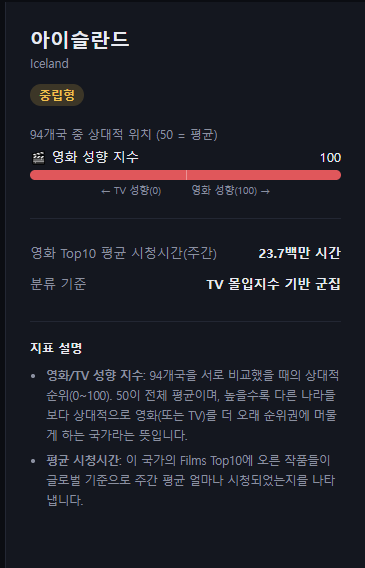
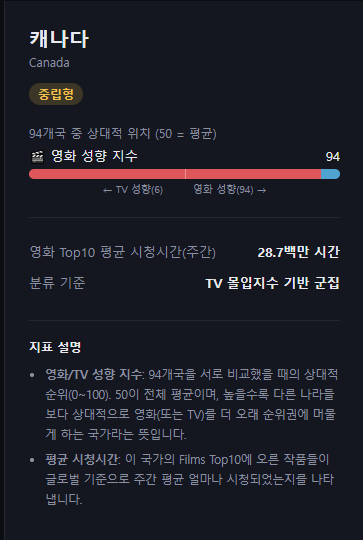
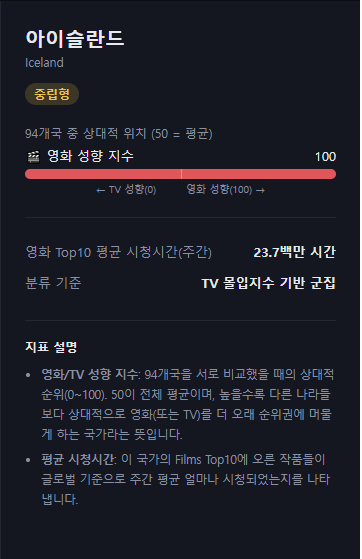
- 중립형으로 표기 되지만 지표가 이상한 경우를 수정
- 94개 국가 중 42개국(거의 절반)이 라벨과 지수가 안 맞았음 — 노르웨이만의 문제가 아니라 구조적인 문제.

# 웹사이트 개선판 v3 - 라벨과 지수 불일치 문제 수정

In [8]:
"""
07. 웹사이트 개선판 v3 - 라벨과 지수 불일치 문제 수정

전제 조건: 아래 스크립트들을 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

06번에서 발견된 문제:
  "성향 라벨"은 K-Means 4개 피처 군집 결과를 쓰고,
  "성향 지수(0~100)"는 tv_stickiness_ratio 하나만으로 계산해서
  서로 다른 기준이라 94개국 중 42개국에서 라벨과 지수가 모순되는 경우가 발생함
  (예: 노르웨이 - 지수는 96(강한 영화 선호)인데 라벨은 "중립형")

07번에서 고친 점:
  라벨(영화 선호형/중립형/드라마 몰입형)을 K-Means 결과 대신
  지수(film_index)를 3등분(pd.qcut)한 값으로 다시 매김
  -> 화면에 보이는 숫자와 라벨이 항상 같은 기준이라 모순이 발생하지 않음
  -> 단, 02번의 K-Means 군집 결과와는 값이 달라질 수 있음
     (군집화 분석 자체는 발표 슬라이드용으로 별도 유효, 이 웹사이트는
      단일 지표 기반의 "직관적 요약판" 성격으로 이해하면 됨)
"""

import json
import pandas as pd

# ---------------------------------------------------------
# 1. 국가명 영→한 매핑
# ---------------------------------------------------------
KOREAN_NAME = {
    "Argentina": "아르헨티나", "Australia": "호주", "Austria": "오스트리아",
    "Bahamas": "바하마", "Bahrain": "바레인", "Bangladesh": "방글라데시",
    "Belgium": "벨기에", "Bolivia": "볼리비아", "Brazil": "브라질",
    "Bulgaria": "불가리아", "Canada": "캐나다", "Chile": "칠레",
    "Colombia": "콜롬비아", "Costa Rica": "코스타리카", "Croatia": "크로아티아",
    "Cyprus": "키프로스", "Czech Republic": "체코", "Denmark": "덴마크",
    "Dominican Republic": "도미니카공화국", "Ecuador": "에콰도르", "Egypt": "이집트",
    "El Salvador": "엘살바도르", "Estonia": "에스토니아", "Finland": "핀란드",
    "France": "프랑스", "Germany": "독일", "Greece": "그리스",
    "Guadeloupe": "과들루프", "Guatemala": "과테말라", "Honduras": "온두라스",
    "Hong Kong": "홍콩", "Hungary": "헝가리", "Iceland": "아이슬란드",
    "India": "인도", "Indonesia": "인도네시아", "Ireland": "아일랜드",
    "Israel": "이스라엘", "Italy": "이탈리아", "Jamaica": "자메이카",
    "Japan": "일본", "Jordan": "요르단", "Kenya": "케냐",
    "Kuwait": "쿠웨이트", "Latvia": "라트비아", "Lebanon": "레바논",
    "Lithuania": "리투아니아", "Luxembourg": "룩셈부르크", "Malaysia": "말레이시아",
    "Maldives": "몰디브", "Malta": "몰타", "Martinique": "마르티니크",
    "Mauritius": "모리셔스", "Mexico": "멕시코", "Morocco": "모로코",
    "Netherlands": "네덜란드", "New Caledonia": "누벨칼레도니", "New Zealand": "뉴질랜드",
    "Nicaragua": "니카라과", "Nigeria": "나이지리아", "Norway": "노르웨이",
    "Oman": "오만", "Pakistan": "파키스탄", "Panama": "파나마",
    "Paraguay": "파라과이", "Peru": "페루", "Philippines": "필리핀",
    "Poland": "폴란드", "Portugal": "포르투갈", "Qatar": "카타르",
    "Romania": "루마니아", "Russia": "러시아", "Réunion": "레위니옹",
    "Saudi Arabia": "사우디아라비아", "Serbia": "세르비아", "Singapore": "싱가포르",
    "Slovakia": "슬로바키아", "Slovenia": "슬로베니아", "South Africa": "남아프리카공화국",
    "South Korea": "대한민국", "Spain": "스페인", "Sri Lanka": "스리랑카",
    "Sweden": "스웨덴", "Switzerland": "스위스", "Taiwan": "대만",
    "Thailand": "태국", "Trinidad and Tobago": "트리니다드토바고",
    "Turkey": "튀르키예", "Ukraine": "우크라이나", "United Arab Emirates": "아랍에미리트",
    "United Kingdom": "영국", "United States": "미국", "Uruguay": "우루과이",
    "Venezuela": "베네수엘라", "Vietnam": "베트남",
}

# ---------------------------------------------------------
# 2. 데이터 로드
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

# ---------------------------------------------------------
# 3. 영화/TV "상대 지수" 계산 (0~100, 50=평균)
#    94개국 사이에서의 백분위 순위(rank pct)로 변환
# ---------------------------------------------------------
clusters["film_index"] = ((-clusters["tv_stickiness_ratio"]).rank(pct=True) * 100).round(0).astype(int)
clusters["tv_index"] = 100 - clusters["film_index"]

# ---------------------------------------------------------
# 4. 성향 라벨을 지수 기준으로 3등분해서 재계산
#    (K-Means 군집 대신 film_index를 그대로 3등분 -> 라벨과 숫자가 항상 일치)
# ---------------------------------------------------------
clusters["tendency"] = pd.qcut(
    clusters["film_index"], 3, labels=["드라마 몰입형", "중립형", "영화 선호형"]
)

# ---------------------------------------------------------
# 5. 평균 시청시간 계산
# ---------------------------------------------------------
film_rows = merged[merged["category"] == "Films"]
avg_hours = (
    film_rows.groupby("country_name")["weekly_hours_viewed"]
    .mean()
    .reset_index()
    .rename(columns={"weekly_hours_viewed": "avg_weekly_hours"})
)

result = clusters.merge(avg_hours, on="country_name", how="left")
result["avg_weekly_hours"] = result["avg_weekly_hours"].fillna(0)

# ---------------------------------------------------------
# 6. 한글 국가명 붙이기
# ---------------------------------------------------------
result["country_name_kr"] = result["country_name"].map(KOREAN_NAME)
missing = result[result["country_name_kr"].isna()]["country_name"].tolist()
if missing:
    print("주의: 한글 명칭 없는 국가:", missing)
    result["country_name_kr"] = result["country_name_kr"].fillna(result["country_name"])

# ---------------------------------------------------------
# 7. 검증: 라벨과 지수가 서로 어긋나지 않는지 확인
# ---------------------------------------------------------
check = result.groupby("tendency")["film_index"].agg(["min", "max", "count"])
print("라벨별 지수 범위 (겹치지 않아야 정상)")
print(check)

# ---------------------------------------------------------
# 8. 웹사이트에 넣을 JSON 데이터 만들기
# ---------------------------------------------------------
site_data = result[[
    "country_name", "country_name_kr", "tendency",
    "film_index", "tv_index", "avg_weekly_hours",
]]
records = site_data.to_dict(orient="records")
print(f"{len(records)}개국 데이터 준비 완료")

# ---------------------------------------------------------
# 9. HTML 템플릿에 데이터 삽입 후 파일 저장
# ---------------------------------------------------------
html_template = """<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>넷플릭스 국가별 시청 성향 지도</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/plotly.js/2.27.0/plotly.min.js"></script>
<style>
  :root {
    --bg: #0b0d12;
    --panel: #14171f;
    --panel-border: #232733;
    --text: #e8eaf0;
    --muted: #8b90a0;
    --film: #e0575b;
    --tv: #4fa3d1;
    --accent: #f2c14e;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    background: var(--bg);
    color: var(--text);
    font-family: -apple-system, "Pretendard", "Apple SD Gothic Neo", "Malgun Gothic", sans-serif;
  }
  header {
    padding: 28px 32px 18px;
    border-bottom: 1px solid var(--panel-border);
  }
  header h1 {
    margin: 0 0 6px;
    font-size: 22px;
    font-weight: 700;
    letter-spacing: -0.01em;
  }
  header p {
    margin: 0;
    color: var(--muted);
    font-size: 14px;
  }
  .layout {
    display: grid;
    grid-template-columns: 1fr 360px;
    gap: 0;
    min-height: calc(100vh - 92px);
  }
  @media (max-width: 860px) {
    .layout { grid-template-columns: 1fr; }
  }
  .map-area {
    padding: 12px;
    position: relative;
  }
  #map {
    width: 100%;
    height: 640px;
  }
  .legend {
    display: flex;
    gap: 18px;
    padding: 0 20px 8px;
    font-size: 12px;
    color: var(--muted);
    flex-wrap: wrap;
  }
  .legend span { display: inline-flex; align-items: center; gap: 6px; }
  .dot { width: 9px; height: 9px; border-radius: 2px; display: inline-block; }
  .panel {
    border-left: 1px solid var(--panel-border);
    padding: 24px;
    background: var(--panel);
  }
  .panel-empty {
    color: var(--muted);
    font-size: 14px;
    line-height: 1.7;
    margin-top: 60px;
    text-align: center;
  }
  .panel-empty .big { font-size: 32px; display: block; margin-bottom: 10px; }
  .country-name {
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 2px;
  }
  .country-name-en {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 12px;
  }
  .tendency-badge {
    display: inline-block;
    font-size: 12px;
    padding: 3px 9px;
    border-radius: 999px;
    margin-bottom: 20px;
    font-weight: 600;
  }
  .badge-film { background: rgba(224,87,91,0.18); color: var(--film); }
  .badge-tv { background: rgba(79,163,209,0.18); color: var(--tv); }
  .badge-neutral { background: rgba(242,193,78,0.18); color: var(--accent); }

  .index-label {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 6px;
  }
  .bar-row { margin-bottom: 16px; }
  .bar-label {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    margin-bottom: 5px;
  }
  .bar-track {
    height: 10px;
    border-radius: 5px;
    background: #232733;
    overflow: hidden;
    display: flex;
    position: relative;
  }
  .bar-fill-film { background: var(--film); height: 100%; }
  .bar-fill-tv { background: var(--tv); height: 100%; }
  .bar-midline {
    position: absolute;
    left: 50%;
    top: -2px;
    bottom: -2px;
    width: 1px;
    background: rgba(255,255,255,0.35);
  }
  .midline-caption {
    font-size: 10px;
    color: var(--muted);
    text-align: center;
    margin-top: 3px;
  }

  .stat-block {
    margin-top: 22px;
    padding-top: 18px;
    border-top: 1px solid var(--panel-border);
  }
  .stat-row {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    padding: 7px 0;
    color: var(--muted);
  }
  .stat-row b { color: var(--text); font-weight: 600; }

  .note {
    margin-top: 22px;
    font-size: 11.5px;
    color: var(--muted);
    line-height: 1.75;
    padding-top: 16px;
    border-top: 1px solid var(--panel-border);
  }
  .note .note-title {
    color: var(--text);
    font-weight: 600;
    margin-bottom: 6px;
    font-size: 12px;
  }
  .note ul {
    margin: 0 0 10px;
    padding-left: 16px;
  }
  .note li { margin-bottom: 4px; }
</style>
</head>
<body>

<header>
  <h1>넷플릭스 국가별 영화 vs TV 시청 성향</h1>
  <p>국가를 클릭하면 다른 국가 대비 상대적인 영화·TV 선호 지수를 확인할 수 있습니다 (2021.07 ~ 2022.01, 94개국 기준)</p>
</header>

<div class="legend">
  <span><span class="dot" style="background:var(--film)"></span>영화 선호형</span>
  <span><span class="dot" style="background:var(--accent)"></span>중립형</span>
  <span><span class="dot" style="background:var(--tv)"></span>드라마 몰입형</span>
</div>

<div class="layout">
  <div class="map-area">
    <div id="map"></div>
  </div>
  <div class="panel" id="panel">
    <div class="panel-empty">
      <span class="big">🌍</span>
      지도에서 국가를 클릭해보세요
    </div>
  </div>
</div>

<script>
const DATA = __COUNTRY_DATA_JSON__;

const dataByName = {};
DATA.forEach(d => { dataByName[d.country_name] = d; });

const tendencyColor = {
  "영화 선호형": "#e0575b",
  "중립형": "#f2c14e",
  "드라마 몰입형": "#4fa3d1"
};
const tendencyOrder = ["영화 선호형", "중립형", "드라마 몰입형"];

const trace = {
  type: "choropleth",
  locationmode: "country names",
  locations: DATA.map(d => d.country_name),
  z: DATA.map(d => tendencyOrder.indexOf(d.tendency)),
  text: DATA.map(d => d.country_name_kr),
  hoverinfo: "text",
  colorscale: [
    [0, "#e0575b"],
    [0.5, "#f2c14e"],
    [1, "#4fa3d1"]
  ],
  showscale: false,
  marker: { line: { color: "#0b0d12", width: 0.6 } }
};

const layout = {
  geo: {
    projection: { type: "natural earth" },
    showframe: false,
    showcoastlines: false,
    bgcolor: "rgba(0,0,0,0)",
    landcolor: "#1c202b",
    showcountries: true,
    countrycolor: "#0b0d12"
  },
  paper_bgcolor: "rgba(0,0,0,0)",
  margin: { l: 0, r: 0, t: 0, b: 0 },
  font: { color: "#e8eaf0" }
};

Plotly.newPlot("map", [trace], layout, { displayModeBar: false, responsive: true });

document.getElementById("map").on("plotly_click", function(evt) {
  const enName = evt.points[0].location;
  const d = dataByName[enName];
  if (d) renderPanel(d);
});

function badgeClass(tendency) {
  if (tendency === "영화 선호형") return "badge-film";
  if (tendency === "드라마 몰입형") return "badge-tv";
  return "badge-neutral";
}

function renderPanel(d) {
  const panel = document.getElementById("panel");
  const avgM = (d.avg_weekly_hours / 1e6).toFixed(1);
  panel.innerHTML = `
    <div class="country-name">${d.country_name_kr}</div>
    <div class="country-name-en">${d.country_name}</div>
    <div class="tendency-badge ${badgeClass(d.tendency)}">${d.tendency}</div>

    <div class="index-label">94개국 중 상대적 위치 (50 = 평균)</div>
    <div class="bar-row">
      <div class="bar-label"><span>🎬 영화 성향 지수</span><span>${d.film_index}</span></div>
      <div class="bar-track">
        <div class="bar-fill-film" style="width:${d.film_index}%"></div>
        <div class="bar-fill-tv" style="width:${d.tv_index}%"></div>
        <div class="bar-midline"></div>
      </div>
      <div class="midline-caption">← TV 성향(${d.tv_index})　　　영화 성향(${d.film_index}) →</div>
    </div>

    <div class="stat-block">
      <div class="stat-row"><span>영화 Top10 평균 시청시간(주간)</span><b>${avgM}백만 시간</b></div>
      <div class="stat-row"><span>분류 기준</span><b>TV 몰입지수 기반 군집</b></div>
    </div>

    <div class="note">
      <div class="note-title">지표 설명</div>
      <ul>
        <li><b>영화/TV 성향 지수</b>: 94개국을 서로 비교했을 때의 상대적 순위(0~100). 50이 전체 평균이며, 높을수록 다른 나라들보다 상대적으로 영화(또는 TV)를 더 오래 순위권에 머물게 하는 국가라는 뜻입니다.</li>
        <li><b>평균 시청시간</b>: 이 국가의 Films Top10에 오른 작품들이 글로벌 기준으로 주간 평균 얼마나 시청되었는지를 나타냅니다.</li>
      </ul>
    </div>
  `;
}
</script>

</body>
</html>
"""

html_output = html_template.replace("__COUNTRY_DATA_JSON__", json.dumps(records, ensure_ascii=False))

output_path = "entertainment_country_map.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_output)

print(f"저장 완료: {output_path}")
print("만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.")

라벨별 지수 범위 (겹치지 않아야 정상)
          min  max  count
tendency                 
드라마 몰입형     1   34     32
중립형        35   67     31
영화 선호형     68  100     31
94개국 데이터 준비 완료
저장 완료: entertainment_country_map.html
만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.


## 변경 내용
- 영화/TV를 나눠 채우던 막대(구성비처럼 보이던 것)를 없애고, 하나의 트랙 위에 점 하나로 위치를 찍는 게이지로 바꿈
- 그 아래 "94개국 중 영화 성향 1위 (지수 100점)"처럼 실제 순위를 텍스트로 같이 보여줘서 이게 "비중"이 아니라 "순위"라는 걸 바로 알 수 있게 했음
- 설명 문구도 "100이라고 해서 영화만 100% 본다는 뜻이 아니라, 94개국 중 가장 치우친 국가라는 뜻"이라고 명시적으로 적음

In [9]:
"""
08. 웹사이트 개선판 v4 - 게이지(순위) 방식으로 시각화 수정

전제 조건: 아래 스크립트들을 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

07번에서 발견된 문제:
  film_index=100인 국가(아이슬란드 등)를 "영화 100% / TV 0%"처럼
  두 색으로 나눠 채우는 막대로 표현해서, 마치 실제 시청 비중이
  100:0인 것처럼 오해하게 만듦. 하지만 이 지수는 어디까지나
  "94개국 중 상대적 순위"이지 실제 시청 비중이 아님.

08번에서 고친 점:
  구성비(채우기) 막대 -> 점(게이지) 위치로 표현 방식을 바꿔서
  "위치/순위"라는 것이 직관적으로 보이도록 수정.
  실제 순위(예: "94개국 중 1위")도 함께 표시해 혼동을 줄임.
"""

import json
import pandas as pd

# ---------------------------------------------------------
# 1. 국가명 영→한 매핑
# ---------------------------------------------------------
KOREAN_NAME = {
    "Argentina": "아르헨티나", "Australia": "호주", "Austria": "오스트리아",
    "Bahamas": "바하마", "Bahrain": "바레인", "Bangladesh": "방글라데시",
    "Belgium": "벨기에", "Bolivia": "볼리비아", "Brazil": "브라질",
    "Bulgaria": "불가리아", "Canada": "캐나다", "Chile": "칠레",
    "Colombia": "콜롬비아", "Costa Rica": "코스타리카", "Croatia": "크로아티아",
    "Cyprus": "키프로스", "Czech Republic": "체코", "Denmark": "덴마크",
    "Dominican Republic": "도미니카공화국", "Ecuador": "에콰도르", "Egypt": "이집트",
    "El Salvador": "엘살바도르", "Estonia": "에스토니아", "Finland": "핀란드",
    "France": "프랑스", "Germany": "독일", "Greece": "그리스",
    "Guadeloupe": "과들루프", "Guatemala": "과테말라", "Honduras": "온두라스",
    "Hong Kong": "홍콩", "Hungary": "헝가리", "Iceland": "아이슬란드",
    "India": "인도", "Indonesia": "인도네시아", "Ireland": "아일랜드",
    "Israel": "이스라엘", "Italy": "이탈리아", "Jamaica": "자메이카",
    "Japan": "일본", "Jordan": "요르단", "Kenya": "케냐",
    "Kuwait": "쿠웨이트", "Latvia": "라트비아", "Lebanon": "레바논",
    "Lithuania": "리투아니아", "Luxembourg": "룩셈부르크", "Malaysia": "말레이시아",
    "Maldives": "몰디브", "Malta": "몰타", "Martinique": "마르티니크",
    "Mauritius": "모리셔스", "Mexico": "멕시코", "Morocco": "모로코",
    "Netherlands": "네덜란드", "New Caledonia": "누벨칼레도니", "New Zealand": "뉴질랜드",
    "Nicaragua": "니카라과", "Nigeria": "나이지리아", "Norway": "노르웨이",
    "Oman": "오만", "Pakistan": "파키스탄", "Panama": "파나마",
    "Paraguay": "파라과이", "Peru": "페루", "Philippines": "필리핀",
    "Poland": "폴란드", "Portugal": "포르투갈", "Qatar": "카타르",
    "Romania": "루마니아", "Russia": "러시아", "Réunion": "레위니옹",
    "Saudi Arabia": "사우디아라비아", "Serbia": "세르비아", "Singapore": "싱가포르",
    "Slovakia": "슬로바키아", "Slovenia": "슬로베니아", "South Africa": "남아프리카공화국",
    "South Korea": "대한민국", "Spain": "스페인", "Sri Lanka": "스리랑카",
    "Sweden": "스웨덴", "Switzerland": "스위스", "Taiwan": "대만",
    "Thailand": "태국", "Trinidad and Tobago": "트리니다드토바고",
    "Turkey": "튀르키예", "Ukraine": "우크라이나", "United Arab Emirates": "아랍에미리트",
    "United Kingdom": "영국", "United States": "미국", "Uruguay": "우루과이",
    "Venezuela": "베네수엘라", "Vietnam": "베트남",
}

# ---------------------------------------------------------
# 2. 데이터 로드
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

# ---------------------------------------------------------
# 3. 영화 성향 지수(0~100, 백분위) + 실제 순위 계산
# ---------------------------------------------------------
clusters["film_index"] = ((-clusters["tv_stickiness_ratio"]).rank(pct=True) * 100).round(0).astype(int)
clusters["film_rank"] = (-clusters["tv_stickiness_ratio"]).rank(ascending=False, method="min").astype(int)

# ---------------------------------------------------------
# 4. 성향 라벨을 지수 기준으로 3등분 (라벨과 숫자가 항상 일치하도록)
# ---------------------------------------------------------
clusters["tendency"] = pd.qcut(
    clusters["film_index"], 3, labels=["드라마 몰입형", "중립형", "영화 선호형"]
)

# ---------------------------------------------------------
# 5. 평균 시청시간 계산
# ---------------------------------------------------------
film_rows = merged[merged["category"] == "Films"]
avg_hours = (
    film_rows.groupby("country_name")["weekly_hours_viewed"]
    .mean()
    .reset_index()
    .rename(columns={"weekly_hours_viewed": "avg_weekly_hours"})
)

result = clusters.merge(avg_hours, on="country_name", how="left")
result["avg_weekly_hours"] = result["avg_weekly_hours"].fillna(0)

# ---------------------------------------------------------
# 6. 한글 국가명 붙이기
# ---------------------------------------------------------
result["country_name_kr"] = result["country_name"].map(KOREAN_NAME)
missing = result[result["country_name_kr"].isna()]["country_name"].tolist()
if missing:
    print("주의: 한글 명칭 없는 국가:", missing)
    result["country_name_kr"] = result["country_name_kr"].fillna(result["country_name"])

# ---------------------------------------------------------
# 7. 웹사이트에 넣을 JSON 데이터 만들기
# ---------------------------------------------------------
site_data = result[[
    "country_name", "country_name_kr", "tendency",
    "film_index", "film_rank", "avg_weekly_hours",
]]
records = site_data.to_dict(orient="records")
print(f"{len(records)}개국 데이터 준비 완료")

# ---------------------------------------------------------
# 8. HTML 템플릿에 데이터 삽입 후 파일 저장
# ---------------------------------------------------------
html_template = """<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>넷플릭스 국가별 시청 성향 지도</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/plotly.js/2.27.0/plotly.min.js"></script>
<style>
  :root {
    --bg: #0b0d12;
    --panel: #14171f;
    --panel-border: #232733;
    --text: #e8eaf0;
    --muted: #8b90a0;
    --film: #e0575b;
    --tv: #4fa3d1;
    --accent: #f2c14e;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    background: var(--bg);
    color: var(--text);
    font-family: -apple-system, "Pretendard", "Apple SD Gothic Neo", "Malgun Gothic", sans-serif;
  }
  header {
    padding: 28px 32px 18px;
    border-bottom: 1px solid var(--panel-border);
  }
  header h1 {
    margin: 0 0 6px;
    font-size: 22px;
    font-weight: 700;
    letter-spacing: -0.01em;
  }
  header p {
    margin: 0;
    color: var(--muted);
    font-size: 14px;
  }
  .layout {
    display: grid;
    grid-template-columns: 1fr 360px;
    gap: 0;
    min-height: calc(100vh - 92px);
  }
  @media (max-width: 860px) {
    .layout { grid-template-columns: 1fr; }
  }
  .map-area {
    padding: 12px;
    position: relative;
  }
  #map {
    width: 100%;
    height: 640px;
  }
  .legend {
    display: flex;
    gap: 18px;
    padding: 0 20px 8px;
    font-size: 12px;
    color: var(--muted);
    flex-wrap: wrap;
  }
  .legend span { display: inline-flex; align-items: center; gap: 6px; }
  .dot { width: 9px; height: 9px; border-radius: 2px; display: inline-block; }
  .panel {
    border-left: 1px solid var(--panel-border);
    padding: 24px;
    background: var(--panel);
  }
  .panel-empty {
    color: var(--muted);
    font-size: 14px;
    line-height: 1.7;
    margin-top: 60px;
    text-align: center;
  }
  .panel-empty .big { font-size: 32px; display: block; margin-bottom: 10px; }
  .country-name {
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 2px;
  }
  .country-name-en {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 12px;
  }
  .tendency-badge {
    display: inline-block;
    font-size: 12px;
    padding: 3px 9px;
    border-radius: 999px;
    margin-bottom: 20px;
    font-weight: 600;
  }
  .badge-film { background: rgba(224,87,91,0.18); color: var(--film); }
  .badge-tv { background: rgba(79,163,209,0.18); color: var(--tv); }
  .badge-neutral { background: rgba(242,193,78,0.18); color: var(--accent); }

  .index-label {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 6px;
  }
  .bar-row { margin-bottom: 16px; }
  .bar-label {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    margin-bottom: 8px;
  }
  .gauge-track {
    position: relative;
    height: 6px;
    border-radius: 3px;
    background: linear-gradient(to right, var(--tv), #3a3f4d 50%, var(--film));
    margin: 0 9px;
  }
  .gauge-mid {
    position: absolute;
    left: 50%;
    top: -4px;
    bottom: -4px;
    width: 1px;
    background: rgba(255,255,255,0.4);
  }
  .gauge-dot {
    position: absolute;
    top: 50%;
    width: 16px;
    height: 16px;
    border-radius: 50%;
    background: #fff;
    border: 3px solid var(--bg);
    box-shadow: 0 0 0 1px rgba(255,255,255,0.5);
    transform: translate(-50%, -50%);
  }
  .gauge-caption {
    display: flex;
    justify-content: space-between;
    font-size: 10px;
    color: var(--muted);
    margin-top: 8px;
  }
  .rank-caption {
    font-size: 12px;
    color: var(--text);
    text-align: center;
    margin-top: 10px;
    padding: 8px;
    background: #1c202b;
    border-radius: 6px;
  }
  .rank-caption b { color: var(--accent); }

  .stat-block {
    margin-top: 22px;
    padding-top: 18px;
    border-top: 1px solid var(--panel-border);
  }
  .stat-row {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    padding: 7px 0;
    color: var(--muted);
  }
  .stat-row b { color: var(--text); font-weight: 600; }

  .note {
    margin-top: 22px;
    font-size: 11.5px;
    color: var(--muted);
    line-height: 1.75;
    padding-top: 16px;
    border-top: 1px solid var(--panel-border);
  }
  .note .note-title {
    color: var(--text);
    font-weight: 600;
    margin-bottom: 6px;
    font-size: 12px;
  }
  .note ul {
    margin: 0 0 10px;
    padding-left: 16px;
  }
  .note li { margin-bottom: 4px; }
</style>
</head>
<body>

<header>
  <h1>넷플릭스 국가별 영화 vs TV 시청 성향</h1>
  <p>국가를 클릭하면 다른 국가 대비 상대적인 영화·TV 선호 지수를 확인할 수 있습니다 (2021.07 ~ 2022.01, 94개국 기준)</p>
</header>

<div class="legend">
  <span><span class="dot" style="background:var(--film)"></span>영화 선호형</span>
  <span><span class="dot" style="background:var(--accent)"></span>중립형</span>
  <span><span class="dot" style="background:var(--tv)"></span>드라마 몰입형</span>
</div>

<div class="layout">
  <div class="map-area">
    <div id="map"></div>
  </div>
  <div class="panel" id="panel">
    <div class="panel-empty">
      <span class="big">🌍</span>
      지도에서 국가를 클릭해보세요
    </div>
  </div>
</div>

<script>
const DATA = __COUNTRY_DATA_JSON__;

const dataByName = {};
DATA.forEach(d => { dataByName[d.country_name] = d; });

const tendencyColor = {
  "영화 선호형": "#e0575b",
  "중립형": "#f2c14e",
  "드라마 몰입형": "#4fa3d1"
};
const tendencyOrder = ["영화 선호형", "중립형", "드라마 몰입형"];

const trace = {
  type: "choropleth",
  locationmode: "country names",
  locations: DATA.map(d => d.country_name),
  z: DATA.map(d => tendencyOrder.indexOf(d.tendency)),
  text: DATA.map(d => d.country_name_kr),
  hoverinfo: "text",
  colorscale: [
    [0, "#e0575b"],
    [0.5, "#f2c14e"],
    [1, "#4fa3d1"]
  ],
  showscale: false,
  marker: { line: { color: "#0b0d12", width: 0.6 } }
};

const layout = {
  geo: {
    projection: { type: "natural earth" },
    showframe: false,
    showcoastlines: false,
    bgcolor: "rgba(0,0,0,0)",
    landcolor: "#1c202b",
    showcountries: true,
    countrycolor: "#0b0d12"
  },
  paper_bgcolor: "rgba(0,0,0,0)",
  margin: { l: 0, r: 0, t: 0, b: 0 },
  font: { color: "#e8eaf0" }
};

Plotly.newPlot("map", [trace], layout, { displayModeBar: false, responsive: true });

document.getElementById("map").on("plotly_click", function(evt) {
  const enName = evt.points[0].location;
  const d = dataByName[enName];
  if (d) renderPanel(d);
});

function badgeClass(tendency) {
  if (tendency === "영화 선호형") return "badge-film";
  if (tendency === "드라마 몰입형") return "badge-tv";
  return "badge-neutral";
}

function renderPanel(d) {
  const panel = document.getElementById("panel");
  const avgM = (d.avg_weekly_hours / 1e6).toFixed(1);
  panel.innerHTML = `
    <div class="country-name">${d.country_name_kr}</div>
    <div class="country-name-en">${d.country_name}</div>
    <div class="tendency-badge ${badgeClass(d.tendency)}">${d.tendency}</div>

    <div class="index-label">94개국 중 상대적 위치를 나타내는 순위 점수입니다 (실제 시청 비중이 아닙니다)</div>
    <div class="bar-row">
      <div class="bar-label"><span>📺 TV 성향</span><span>영화 성향 🎬</span></div>
      <div class="gauge-track">
        <div class="gauge-mid"></div>
        <div class="gauge-dot" style="left:${d.film_index}%"></div>
      </div>
      <div class="gauge-caption"><span>0 (TV 몰입 극단)</span><span>50 (평균)</span><span>100 (영화 선호 극단)</span></div>
      <div class="rank-caption">94개국 중 영화 성향 <b>${d.film_rank}위</b> (지수 ${d.film_index}점)</div>
    </div>

    <div class="stat-block">
      <div class="stat-row"><span>영화 Top10 평균 시청시간(주간)</span><b>${avgM}백만 시간</b></div>
      <div class="stat-row"><span>분류 기준</span><b>TV 몰입지수 기반 군집</b></div>
    </div>

    <div class="note">
      <div class="note-title">지표 설명</div>
      <ul>
        <li><b>영화 성향 지수</b>: 94개국을 서로 비교한 상대적 "순위 점수"(0~100)입니다. 100이라고 해서 영화만 100% 본다는 뜻이 아니라, "94개국 중 영화 쪽으로 가장 치우친 국가"라는 뜻입니다. 실제 시청 비중과는 다릅니다.</li>
        <li><b>평균 시청시간</b>: 이 국가의 Films Top10에 오른 작품들이 글로벌 기준으로 주간 평균 얼마나 시청되었는지를 나타냅니다.</li>
      </ul>
    </div>
  `;
}
</script>

</body>
</html>
"""

html_output = html_template.replace("__COUNTRY_DATA_JSON__", json.dumps(records, ensure_ascii=False))

output_path = "entertainment_country_map.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_output)

print(f"저장 완료: {output_path}")
print("만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.")

94개국 데이터 준비 완료
저장 완료: entertainment_country_map.html
만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.


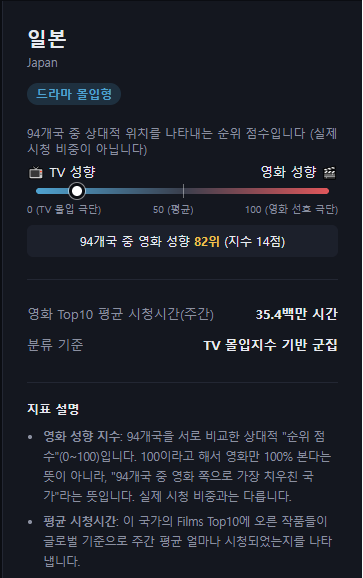
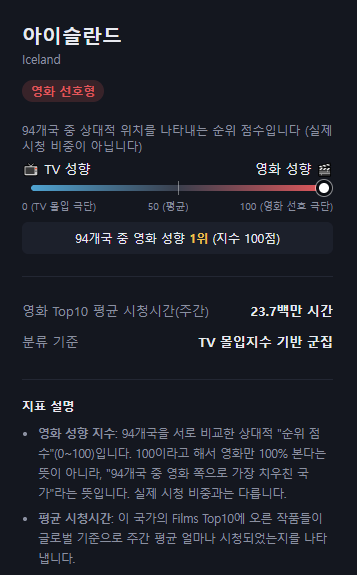
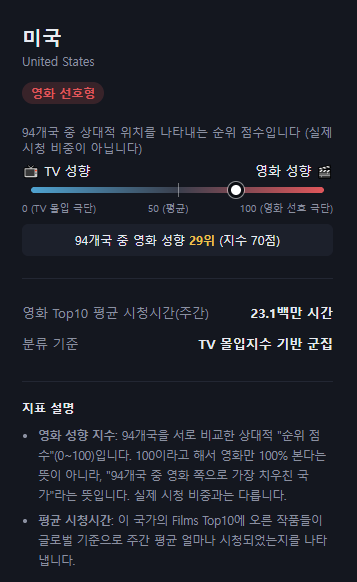
- 상기 사진들에는 현재 그래프가 영화 성향 순위에 따라 영화 성향으로 가고 있지만
  그 나라의 영화와 TV시청 비율을 알고 싶음.
- 하지만 현재 데이터에는 실제로 몇 시간을 봤는지는 국가단위로 존재하지 않음.
- 새로운 데이터를 수집해 필요한 그래프를 만들 예정.


# 실제 넷플릭스 이용자 3만명 국가별 영화 TV 데이터
- 출저 https://www.comparitech.com/tv-streaming/netflix-viewing-time-by-country/
- 현재 조사중인 94개국 전체에 대한 데이터는 찾지 못 했음.
- 국가별 넷플릭스 이용자 3만명에 대한 54개국의 데이터

### 사이트에는 2022년 11월 21일 업데이트 되어있지만 2021년 데이터도 존재하는 이유
- 페이지를 가져왔을 때(웹 크롤링), 눈에 보이는 본문 텍스트 말고 페이지 안쪽에 숨겨진 메타데이터(HTMT meta 테그)에 하기와 같이 적혀있음
1. meta-article:published_time: 2021-03-29T07:00:27+00:00
2. meta-article:modified_time: 2022-11-21T00:00:00Z
3. 상기 내용이 말해주는 것이 최초 발행은 2021년 3월 최종 업데이트가 2022년 11월 이라는 뜻

## 공식사이트의 데이터로 하지 않은 이유
- 넷플릭스 공식 사이트에서 제공하는 파일에는 국가별 순위(1~10위)만 나오고 시청 시간이나 시청 횟수 데이터는 포함되어 있지 않음.
- 시청시간이 나오는 데이터가 있었지만 전 세계 합산 기준이라 개별 국가의 영화와 TV 비중을 직접 계산하기에는 한계가 있음.

In [15]:
"""
09. Comparitech 실측 데이터를 기존 데이터에 병합

전제 조건: 아래 스크립트들을 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

출처: Comparitech, "Which country watches the most Netflix?"
      https://www.comparitech.com/tv-streaming/netflix-viewing-time-by-country/
      (2021.3 발행, 2022.11 업데이트 / 넷플릭스 이용자 약 3만명의
       자발적 업로드 시청기록 기반 - 가입 이후 누적 시청 데이터)

이 스크립트가 하는 일:
  1) 스크린샷으로 받은 Comparitech 표(52개국)를 REAL_DATA로 정의
  2) 기존 파이프라인(01, 02번 결과)으로 계산한 film_index(순위 기반 추정치)에
     실측 데이터를 덮어씌워서(병합) 하나의 파일로 저장
  3) 각 국가가 "실측"인지 "추정"인지 data_source 컬럼으로 구분해서 남김
     (지도에는 다음 단계에서 반영 예정 - 이번 스크립트는 데이터 준비까지만)

주의: 우리 자체 데이터(2021.7~2022.1, Top10 화제작 기준)와
      Comparitech 데이터(가입 이후 전체 누적 시청 기준)는 측정 방식이
      서로 다르므로, 같은 "비율"이라도 의미가 다르다는 점을 유의해야 함
"""

import pandas as pd

# ---------------------------------------------------------
# 1. Comparitech 실측 데이터 (52개국)
#    형식: 국가명 -> (평균 시청분(시리즈), 평균 시청분(영화), % TV, % 영화)
# ---------------------------------------------------------
# Comparitech 실측 데이터 (2021.3 발행, 2022.11 업데이트)
# https://www.comparitech.com/tv-streaming/netflix-viewing-time-by-country/
# 컬럼: 국가명(영문, 우리 데이터셋의 country_name과 동일 표기),
#       평균 시청분(시리즈), 평균 시청분(영화), % TV, % 영화
REAL_DATA = {
    "Argentina": (92124, 16352, 84.93, 15.07),
    "Australia": (52673, 15144, 77.67, 22.33),
    "Austria": (50250, 9422, 84.21, 15.79),
    "Belgium": (60102, 13883, 81.24, 18.76),
    "Brazil": (80512, 15240, 84.08, 15.92),
    "Bulgaria": (44122, 4253, 91.21, 8.79),
    "Canada": (75979, 18669, 80.28, 19.72),
    "Chile": (85159, 13212, 86.57, 13.43),
    "Colombia": (65045, 17461, 78.84, 21.16),
    "Croatia": (35854, 8281, 81.24, 18.76),
    "Cyprus": (50616, 3774, 93.06, 6.94),
    "Czech Republic": (33380, 8541, 79.63, 20.37),
    "Denmark": (55682, 16396, 77.25, 22.75),
    "Egypt": (54238, 7953, 87.21, 12.79),
    "Estonia": (39622, 6555, 85.80, 14.20),
    "Finland": (52344, 13990, 78.91, 21.09),
    "France": (65081, 12553, 83.83, 16.17),
    "Germany": (54272, 11969, 81.93, 18.07),
    "Greece": (51040, 7672, 86.93, 13.07),
    "Hungary": (33559, 6068, 84.69, 15.31),
    "Iceland": (44690, 6105, 87.98, 12.02),
    "India": (50480, 15813, 76.15, 23.85),
    "Indonesia": (32767, 7100, 82.19, 17.81),
    "Ireland": (60931, 14909, 80.34, 19.66),
    "Israel": (50641, 6578, 88.50, 11.50),
    "Italy": (52725, 12733, 80.55, 19.45),
    "Latvia": (44509, 7782, 85.12, 14.88),
    "Lebanon": (56502, 5921, 90.51, 9.49),
    "Lithuania": (32666, 5283, 86.08, 13.92),
    "Malta": (32835, 4910, 86.99, 13.01),
    "Mexico": (77259, 19266, 80.04, 19.96),
    "Netherlands": (57950, 15663, 78.72, 21.28),
    "New Zealand": (55884, 18220, 75.41, 24.59),
    "Norway": (55165, 14507, 79.18, 20.82),
    "Peru": (87439, 31336, 73.62, 26.38),
    "Poland": (45166, 10407, 81.27, 18.73),
    "Portugal": (55467, 10098, 84.60, 15.40),
    "Qatar": (27961, 2850, 90.75, 9.25),
    "Romania": (58801, 15449, 79.19, 20.81),
    "Saudi Arabia": (49309, 8266, 85.64, 14.36),
    "Serbia": (43399, 10114, 81.10, 18.90),
    "Singapore": (59259, 4018, 93.65, 6.35),
    "Slovakia": (27678, 6738, 80.42, 19.58),
    "Slovenia": (45419, 6163, 88.05, 11.95),
    "South Africa": (54815, 10689, 83.68, 16.32),
    "Spain": (62949, 13033, 82.85, 17.15),
    "Sweden": (58159, 16568, 77.83, 22.17),
    "Switzerland": (66748, 13859, 82.81, 17.19),
    "Turkey": (33777, 5991, 84.94, 15.06),
    "United Arab Emirates": (42419, 15249, 73.56, 26.44),
    "United Kingdom": (62520, 16354, 79.27, 20.73),
    "United States": (75282, 13362, 84.93, 15.07),
}

# ---------------------------------------------------------
# 2. 기존 파이프라인 결과 로드 (02번 군집화 + film_index 계산)
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

# film_index: 94개국 사이 상대 순위 (0~100, 08번과 동일 로직)
clusters["film_index"] = ((-clusters["tv_stickiness_ratio"]).rank(pct=True) * 100).round(0).astype(int)
clusters["film_rank"] = (-clusters["tv_stickiness_ratio"]).rank(ascending=False, method="min").astype(int)
clusters["tendency"] = pd.qcut(
    clusters["film_index"], 3, labels=["드라마 몰입형", "중립형", "영화 선호형"]
)

# 평균 시청시간(우리 자체 데이터 기준)
film_rows = merged[merged["category"] == "Films"]
avg_hours = (
    film_rows.groupby("country_name")["weekly_hours_viewed"]
    .mean()
    .reset_index()
    .rename(columns={"weekly_hours_viewed": "avg_weekly_hours"})
)
result = clusters.merge(avg_hours, on="country_name", how="left")
result["avg_weekly_hours"] = result["avg_weekly_hours"].fillna(0)

# ---------------------------------------------------------
# 3. 실측 데이터 병합 (덮어씌우기)
# ---------------------------------------------------------
def lookup_real(country, idx):
    entry = REAL_DATA.get(country)
    return entry[idx] if entry else None

result["real_avg_min_series"] = result["country_name"].apply(lambda c: lookup_real(c, 0))
result["real_avg_min_movies"] = result["country_name"].apply(lambda c: lookup_real(c, 1))
result["real_tv_pct"] = result["country_name"].apply(lambda c: lookup_real(c, 2))
result["real_film_pct"] = result["country_name"].apply(lambda c: lookup_real(c, 3))

result["data_source"] = result["real_film_pct"].apply(
    lambda v: "실측(Comparitech)" if pd.notna(v) else "추정(순위 기반 지표)"
)

# ---------------------------------------------------------
# 4. 검증 출력
# ---------------------------------------------------------
n_real = (result["data_source"] == "실측(Comparitech)").sum()
n_est = (result["data_source"] == "추정(순위 기반 지표)").sum()
print(f"실측 데이터 있는 국가: {n_real}개국")
print(f"추정치만 있는 국가: {n_est}개국")
print()
print("병합 결과 미리보기 (실측 데이터 있는 국가)")
preview_cols = ["country_name", "film_index", "real_film_pct", "data_source"]
print(result[result["data_source"] == "실측(Comparitech)"][preview_cols].head(10).to_string(index=False))

# ---------------------------------------------------------
# 5. 저장
# ---------------------------------------------------------
output_cols = [
    "country_name", "tendency", "film_index", "film_rank", "avg_weekly_hours",
    "real_tv_pct", "real_film_pct", "real_avg_min_series", "real_avg_min_movies",
    "data_source",
]
result[output_cols].to_csv("country_data_final.csv", index=False, encoding="utf-8-sig")
print()
print("저장 완료: country_data_final.csv")
print("(다음 단계에서 이 파일을 지도 웹사이트에 반영할 예정)")

실측 데이터 있는 국가: 52개국
추정치만 있는 국가: 42개국

병합 결과 미리보기 (실측 데이터 있는 국가)
country_name  film_index  real_film_pct     data_source
   Argentina          20          15.07 실측(Comparitech)
   Australia          77          22.33 실측(Comparitech)
     Austria          76          15.79 실측(Comparitech)
     Belgium          84          18.76 실측(Comparitech)
      Brazil          16          15.92 실측(Comparitech)
    Bulgaria          74           8.79 실측(Comparitech)
      Canada          94          19.72 실측(Comparitech)
       Chile          18          13.43 실측(Comparitech)
    Colombia          11          21.16 실측(Comparitech)
     Croatia          99          18.76 실측(Comparitech)

저장 완료: country_data_final.csv
(다음 단계에서 이 파일을 지도 웹사이트에 반영할 예정)


In [17]:
"""
10. 웹사이트 개선판 v5 - 실측 데이터(Comparitech) 반영판

전제 조건: 아래 스크립트들을 먼저 실행해서 결과 파일이 있어야 함
  01_merge_and_check_columns.py  -> merged_countries_with_hours.csv
  02_country_clustering.py       -> country_clusters.csv

08번(게이지 방식)에서 이번에 반영한 요청사항:
  1) 52개국(Comparitech 실측 있는 국가)은 실제 TV비중/영화비중(%)을 표기,
     나머지 42개국은 "업데이트 예정" 문구로 대체
  2) "영화 Top10 평균 시청시간(백만시간)" 대신 "인당 누적 시청일수"로 변경
     -> Comparitech 원본이 "가입 이후 누적 시청시간"이라 연간/하루 평균이
        아니므로, 라벨을 "누적"으로 정확히 표기하고 24시간 기준 '일' 단위로
        환산해서 큰 시간 숫자를 줄임 (예: 263.6시간 -> 11.0일) (52개국만 가능)
     -> 실측 없는 42개국은 이 항목도 "업데이트 예정"
  3) "분류 기준: TV 몰입지수 기반 군집" 문구 삭제
  4) 지표 설명 아래에 "TV/영화 비중은 이 국가의 전체 시청시간 기준이며
     Top10 콘텐츠에 국한된 수치가 아니다"라는 설명 추가

주의: 08번의 "영화 성향 지수" 게이지(94개국 전체, 상대 순위 기반)는
      이번 요청과 무관한 별개 지표라 그대로 유지했고, 그 아래에
      "실제 시청 비중" 섹션을 새로 추가하는 구조로 만들었음
"""

import json
import math
import pandas as pd

# ---------------------------------------------------------
# 1. 국가명 영→한 매핑
# ---------------------------------------------------------
KOREAN_NAME = {
    "Argentina": "아르헨티나", "Australia": "호주", "Austria": "오스트리아",
    "Bahamas": "바하마", "Bahrain": "바레인", "Bangladesh": "방글라데시",
    "Belgium": "벨기에", "Bolivia": "볼리비아", "Brazil": "브라질",
    "Bulgaria": "불가리아", "Canada": "캐나다", "Chile": "칠레",
    "Colombia": "콜롬비아", "Costa Rica": "코스타리카", "Croatia": "크로아티아",
    "Cyprus": "키프로스", "Czech Republic": "체코", "Denmark": "덴마크",
    "Dominican Republic": "도미니카공화국", "Ecuador": "에콰도르", "Egypt": "이집트",
    "El Salvador": "엘살바도르", "Estonia": "에스토니아", "Finland": "핀란드",
    "France": "프랑스", "Germany": "독일", "Greece": "그리스",
    "Guadeloupe": "과들루프", "Guatemala": "과테말라", "Honduras": "온두라스",
    "Hong Kong": "홍콩", "Hungary": "헝가리", "Iceland": "아이슬란드",
    "India": "인도", "Indonesia": "인도네시아", "Ireland": "아일랜드",
    "Israel": "이스라엘", "Italy": "이탈리아", "Jamaica": "자메이카",
    "Japan": "일본", "Jordan": "요르단", "Kenya": "케냐",
    "Kuwait": "쿠웨이트", "Latvia": "라트비아", "Lebanon": "레바논",
    "Lithuania": "리투아니아", "Luxembourg": "룩셈부르크", "Malaysia": "말레이시아",
    "Maldives": "몰디브", "Malta": "몰타", "Martinique": "마르티니크",
    "Mauritius": "모리셔스", "Mexico": "멕시코", "Morocco": "모로코",
    "Netherlands": "네덜란드", "New Caledonia": "누벨칼레도니", "New Zealand": "뉴질랜드",
    "Nicaragua": "니카라과", "Nigeria": "나이지리아", "Norway": "노르웨이",
    "Oman": "오만", "Pakistan": "파키스탄", "Panama": "파나마",
    "Paraguay": "파라과이", "Peru": "페루", "Philippines": "필리핀",
    "Poland": "폴란드", "Portugal": "포르투갈", "Qatar": "카타르",
    "Romania": "루마니아", "Russia": "러시아", "Réunion": "레위니옹",
    "Saudi Arabia": "사우디아라비아", "Serbia": "세르비아", "Singapore": "싱가포르",
    "Slovakia": "슬로바키아", "Slovenia": "슬로베니아", "South Africa": "남아프리카공화국",
    "South Korea": "대한민국", "Spain": "스페인", "Sri Lanka": "스리랑카",
    "Sweden": "스웨덴", "Switzerland": "스위스", "Taiwan": "대만",
    "Thailand": "태국", "Trinidad and Tobago": "트리니다드토바고",
    "Turkey": "튀르키예", "Ukraine": "우크라이나", "United Arab Emirates": "아랍에미리트",
    "United Kingdom": "영국", "United States": "미국", "Uruguay": "우루과이",
    "Venezuela": "베네수엘라", "Vietnam": "베트남",
}

# ---------------------------------------------------------
# 2. Comparitech 실측 데이터 (52개국, 09번과 동일)
#    형식: 국가명 -> (평균 시청분(시리즈), 평균 시청분(영화), % TV, % 영화)
# ---------------------------------------------------------
REAL_DATA = {
    "Argentina": (92124, 16352, 84.93, 15.07),
    "Australia": (52673, 15144, 77.67, 22.33),
    "Austria": (50250, 9422, 84.21, 15.79),
    "Belgium": (60102, 13883, 81.24, 18.76),
    "Brazil": (80512, 15240, 84.08, 15.92),
    "Bulgaria": (44122, 4253, 91.21, 8.79),
    "Canada": (75979, 18669, 80.28, 19.72),
    "Chile": (85159, 13212, 86.57, 13.43),
    "Colombia": (65045, 17461, 78.84, 21.16),
    "Croatia": (35854, 8281, 81.24, 18.76),
    "Cyprus": (50616, 3774, 93.06, 6.94),
    "Czech Republic": (33380, 8541, 79.63, 20.37),
    "Denmark": (55682, 16396, 77.25, 22.75),
    "Egypt": (54238, 7953, 87.21, 12.79),
    "Estonia": (39622, 6555, 85.80, 14.20),
    "Finland": (52344, 13990, 78.91, 21.09),
    "France": (65081, 12553, 83.83, 16.17),
    "Germany": (54272, 11969, 81.93, 18.07),
    "Greece": (51040, 7672, 86.93, 13.07),
    "Hungary": (33559, 6068, 84.69, 15.31),
    "Iceland": (44690, 6105, 87.98, 12.02),
    "India": (50480, 15813, 76.15, 23.85),
    "Indonesia": (32767, 7100, 82.19, 17.81),
    "Ireland": (60931, 14909, 80.34, 19.66),
    "Israel": (50641, 6578, 88.50, 11.50),
    "Italy": (52725, 12733, 80.55, 19.45),
    "Latvia": (44509, 7782, 85.12, 14.88),
    "Lebanon": (56502, 5921, 90.51, 9.49),
    "Lithuania": (32666, 5283, 86.08, 13.92),
    "Malta": (32835, 4910, 86.99, 13.01),
    "Mexico": (77259, 19266, 80.04, 19.96),
    "Netherlands": (57950, 15663, 78.72, 21.28),
    "New Zealand": (55884, 18220, 75.41, 24.59),
    "Norway": (55165, 14507, 79.18, 20.82),
    "Peru": (87439, 31336, 73.62, 26.38),
    "Poland": (45166, 10407, 81.27, 18.73),
    "Portugal": (55467, 10098, 84.60, 15.40),
    "Qatar": (27961, 2850, 90.75, 9.25),
    "Romania": (58801, 15449, 79.19, 20.81),
    "Saudi Arabia": (49309, 8266, 85.64, 14.36),
    "Serbia": (43399, 10114, 81.10, 18.90),
    "Singapore": (59259, 4018, 93.65, 6.35),
    "Slovakia": (27678, 6738, 80.42, 19.58),
    "Slovenia": (45419, 6163, 88.05, 11.95),
    "South Africa": (54815, 10689, 83.68, 16.32),
    "Spain": (62949, 13033, 82.85, 17.15),
    "Sweden": (58159, 16568, 77.83, 22.17),
    "Switzerland": (66748, 13859, 82.81, 17.19),
    "Turkey": (33777, 5991, 84.94, 15.06),
    "United Arab Emirates": (42419, 15249, 73.56, 26.44),
    "United Kingdom": (62520, 16354, 79.27, 20.73),
    "United States": (75282, 13362, 84.93, 15.07),
}

# ---------------------------------------------------------
# 3. 데이터 로드 (01, 02번 결과)
# ---------------------------------------------------------
clusters = pd.read_csv("country_clusters.csv", encoding="utf-8-sig")
merged = pd.read_csv("merged_countries_with_hours.csv", encoding="utf-8-sig")

# ---------------------------------------------------------
# 4. 영화 성향 지수(0~100) + 순위 + 라벨 (08번과 동일 로직, 그대로 유지)
# ---------------------------------------------------------
clusters["film_index"] = ((-clusters["tv_stickiness_ratio"]).rank(pct=True) * 100).round(0).astype(int)
clusters["film_rank"] = (-clusters["tv_stickiness_ratio"]).rank(ascending=False, method="min").astype(int)
clusters["tendency"] = pd.qcut(
    clusters["film_index"], 3, labels=["드라마 몰입형", "중립형", "영화 선호형"]
)

result = clusters.copy()

# ---------------------------------------------------------
# 5. 한글 국가명 붙이기
# ---------------------------------------------------------
result["country_name_kr"] = result["country_name"].map(KOREAN_NAME)
missing = result[result["country_name_kr"].isna()]["country_name"].tolist()
if missing:
    print("주의: 한글 명칭 없는 국가:", missing)
    result["country_name_kr"] = result["country_name_kr"].fillna(result["country_name"])

# ---------------------------------------------------------
# 6. 실측 데이터(Comparitech) 병합
#    - real_tv_pct / real_film_pct: 실제 비중(%)
#    - real_avg_hours_movies / real_avg_hours_series: 인당 평균 시청시간(시간)
#      (Comparitech 원본은 '분' 단위라 60으로 나눠 시간으로 환산)
#    - has_real: 이 국가가 실측 데이터 보유 여부 (52개국만 True)
# ---------------------------------------------------------
def lookup_real(country, idx):
    entry = REAL_DATA.get(country)
    return entry[idx] if entry else None

result["real_avg_min_series"] = result["country_name"].apply(lambda c: lookup_real(c, 0))
result["real_avg_min_movies"] = result["country_name"].apply(lambda c: lookup_real(c, 1))
result["real_tv_pct"] = result["country_name"].apply(lambda c: lookup_real(c, 2))
result["real_film_pct"] = result["country_name"].apply(lambda c: lookup_real(c, 3))

result["real_avg_days_series"] = (result["real_avg_min_series"] / 60 / 24).round(1)
result["real_avg_days_movies"] = (result["real_avg_min_movies"] / 60 / 24).round(1)

result["has_real"] = result["real_film_pct"].notna()

n_real = int(result["has_real"].sum())
n_est = int((~result["has_real"]).sum())
print(f"실측 데이터 있는 국가: {n_real}개국 / 업데이트 예정 국가: {n_est}개국")

# ---------------------------------------------------------
# 7. 웹사이트에 넣을 JSON 데이터 만들기
#    NaN은 JSON에서 유효하지 않으므로 None으로 치환
# ---------------------------------------------------------
site_cols = [
    "country_name", "country_name_kr", "tendency",
    "film_index", "film_rank",
    "has_real", "real_tv_pct", "real_film_pct",
    "real_avg_days_series", "real_avg_days_movies",
]
site_data = result[site_cols].copy()
site_data = site_data.astype(object).where(pd.notnull(site_data), None)
records = site_data.to_dict(orient="records")
print(f"{len(records)}개국 데이터 준비 완료")

# ---------------------------------------------------------
# 8. HTML 템플릿에 데이터 삽입 후 파일 저장
# ---------------------------------------------------------
html_template = """<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>넷플릭스 국가별 시청 성향 지도</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/plotly.js/2.27.0/plotly.min.js"></script>
<style>
  :root {
    --bg: #0b0d12;
    --panel: #14171f;
    --panel-border: #232733;
    --text: #e8eaf0;
    --muted: #8b90a0;
    --film: #e0575b;
    --tv: #4fa3d1;
    --accent: #f2c14e;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    background: var(--bg);
    color: var(--text);
    font-family: -apple-system, "Pretendard", "Apple SD Gothic Neo", "Malgun Gothic", sans-serif;
  }
  header {
    padding: 28px 32px 18px;
    border-bottom: 1px solid var(--panel-border);
  }
  header h1 {
    margin: 0 0 6px;
    font-size: 22px;
    font-weight: 700;
    letter-spacing: -0.01em;
  }
  header p {
    margin: 0;
    color: var(--muted);
    font-size: 14px;
  }
  .layout {
    display: grid;
    grid-template-columns: 1fr 360px;
    gap: 0;
    min-height: calc(100vh - 92px);
  }
  @media (max-width: 860px) {
    .layout { grid-template-columns: 1fr; }
  }
  .map-area {
    padding: 12px;
    position: relative;
  }
  #map {
    width: 100%;
    height: 640px;
  }
  .legend {
    display: flex;
    gap: 18px;
    padding: 0 20px 8px;
    font-size: 12px;
    color: var(--muted);
    flex-wrap: wrap;
  }
  .legend span { display: inline-flex; align-items: center; gap: 6px; }
  .dot { width: 9px; height: 9px; border-radius: 2px; display: inline-block; }
  .panel {
    border-left: 1px solid var(--panel-border);
    padding: 24px;
    background: var(--panel);
  }
  .panel-empty {
    color: var(--muted);
    font-size: 14px;
    line-height: 1.7;
    margin-top: 60px;
    text-align: center;
  }
  .panel-empty .big { font-size: 32px; display: block; margin-bottom: 10px; }
  .country-name {
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 2px;
  }
  .country-name-en {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 12px;
  }
  .tendency-badge {
    display: inline-block;
    font-size: 12px;
    padding: 3px 9px;
    border-radius: 999px;
    margin-bottom: 20px;
    font-weight: 600;
  }
  .badge-film { background: rgba(224,87,91,0.18); color: var(--film); }
  .badge-tv { background: rgba(79,163,209,0.18); color: var(--tv); }
  .badge-neutral { background: rgba(242,193,78,0.18); color: var(--accent); }

  .index-label {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 6px;
  }
  .bar-row { margin-bottom: 16px; }
  .bar-label {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    margin-bottom: 8px;
  }
  .gauge-track {
    position: relative;
    height: 6px;
    border-radius: 3px;
    background: linear-gradient(to right, var(--tv), #3a3f4d 50%, var(--film));
    margin: 0 9px;
  }
  .gauge-mid {
    position: absolute;
    left: 50%;
    top: -4px;
    bottom: -4px;
    width: 1px;
    background: rgba(255,255,255,0.4);
  }
  .gauge-dot {
    position: absolute;
    top: 50%;
    width: 16px;
    height: 16px;
    border-radius: 50%;
    background: #fff;
    border: 3px solid var(--bg);
    box-shadow: 0 0 0 1px rgba(255,255,255,0.5);
    transform: translate(-50%, -50%);
  }
  .gauge-caption {
    display: flex;
    justify-content: space-between;
    font-size: 10px;
    color: var(--muted);
    margin-top: 8px;
  }
  .rank-caption {
    font-size: 12px;
    color: var(--text);
    text-align: center;
    margin-top: 10px;
    padding: 8px;
    background: #1c202b;
    border-radius: 6px;
  }
  .rank-caption b { color: var(--accent); }

  .stat-block {
    margin-top: 22px;
    padding-top: 18px;
    border-top: 1px solid var(--panel-border);
  }
  .stat-block-title {
    font-size: 12px;
    color: var(--muted);
    margin-bottom: 10px;
  }
  .stat-row {
    display: flex;
    justify-content: space-between;
    font-size: 13px;
    padding: 7px 0;
    color: var(--muted);
  }
  .stat-row b { color: var(--text); font-weight: 600; }

  .pending-box {
    margin-top: 6px;
    padding: 14px;
    background: #1c202b;
    border-radius: 6px;
    font-size: 12.5px;
    color: var(--muted);
    text-align: center;
    line-height: 1.6;
  }
  .pending-box b { color: var(--accent); }

  .note {
    margin-top: 22px;
    font-size: 11.5px;
    color: var(--muted);
    line-height: 1.75;
    padding-top: 16px;
    border-top: 1px solid var(--panel-border);
  }
  .note .note-title {
    color: var(--text);
    font-weight: 600;
    margin-bottom: 6px;
    font-size: 12px;
  }
  .note ul {
    margin: 0 0 10px;
    padding-left: 16px;
  }
  .note li { margin-bottom: 4px; }
</style>
</head>
<body>

<header>
  <h1>넷플릭스 국가별 영화 vs TV 시청 성향</h1>
  <p>국가를 클릭하면 다른 국가 대비 상대적인 영화·TV 선호 지수와 실제 시청 비중을 확인할 수 있습니다 (94개국 기준)</p>
</header>

<div class="legend">
  <span><span class="dot" style="background:var(--film)"></span>영화 선호형</span>
  <span><span class="dot" style="background:var(--accent)"></span>중립형</span>
  <span><span class="dot" style="background:var(--tv)"></span>드라마 몰입형</span>
</div>

<div class="layout">
  <div class="map-area">
    <div id="map"></div>
  </div>
  <div class="panel" id="panel">
    <div class="panel-empty">
      <span class="big">🌍</span>
      지도에서 국가를 클릭해보세요
    </div>
  </div>
</div>

<script>
const DATA = __COUNTRY_DATA_JSON__;

const dataByName = {};
DATA.forEach(d => { dataByName[d.country_name] = d; });

const tendencyColor = {
  "영화 선호형": "#e0575b",
  "중립형": "#f2c14e",
  "드라마 몰입형": "#4fa3d1"
};
const tendencyOrder = ["영화 선호형", "중립형", "드라마 몰입형"];

const trace = {
  type: "choropleth",
  locationmode: "country names",
  locations: DATA.map(d => d.country_name),
  z: DATA.map(d => tendencyOrder.indexOf(d.tendency)),
  text: DATA.map(d => d.country_name_kr),
  hoverinfo: "text",
  colorscale: [
    [0, "#e0575b"],
    [0.5, "#f2c14e"],
    [1, "#4fa3d1"]
  ],
  showscale: false,
  marker: { line: { color: "#0b0d12", width: 0.6 } }
};

const layout = {
  geo: {
    projection: { type: "natural earth" },
    showframe: false,
    showcoastlines: false,
    bgcolor: "rgba(0,0,0,0)",
    landcolor: "#1c202b",
    showcountries: true,
    countrycolor: "#0b0d12"
  },
  paper_bgcolor: "rgba(0,0,0,0)",
  margin: { l: 0, r: 0, t: 0, b: 0 },
  font: { color: "#e8eaf0" }
};

Plotly.newPlot("map", [trace], layout, { displayModeBar: false, responsive: true });

document.getElementById("map").on("plotly_click", function(evt) {
  const enName = evt.points[0].location;
  const d = dataByName[enName];
  if (d) renderPanel(d);
});

function badgeClass(tendency) {
  if (tendency === "영화 선호형") return "badge-film";
  if (tendency === "드라마 몰입형") return "badge-tv";
  return "badge-neutral";
}

function renderPanel(d) {
  const panel = document.getElementById("panel");

  const realBlock = d.has_real ? `
    <div class="stat-row"><span>TV 비중</span><b>${d.real_tv_pct}%</b></div>
    <div class="stat-row"><span>영화 비중</span><b>${d.real_film_pct}%</b></div>
    <div class="stat-row"><span>인당 누적 시청일수(시리즈)</span><b>${d.real_avg_days_series}일</b></div>
    <div class="stat-row"><span>인당 누적 시청일수(영화)</span><b>${d.real_avg_days_movies}일</b></div>
  ` : `
    <div class="pending-box"><b>업데이트 예정</b><br>이 국가는 아직 실측 데이터가 준비되지 않았습니다.</div>
  `;

  panel.innerHTML = `
    <div class="country-name">${d.country_name_kr}</div>
    <div class="country-name-en">${d.country_name}</div>
    <div class="tendency-badge ${badgeClass(d.tendency)}">${d.tendency}</div>

    <div class="index-label">94개국 중 상대적 위치를 나타내는 순위 점수입니다 (실제 시청 비중이 아닙니다)</div>
    <div class="bar-row">
      <div class="bar-label"><span>📺 TV 성향</span><span>영화 성향 🎬</span></div>
      <div class="gauge-track">
        <div class="gauge-mid"></div>
        <div class="gauge-dot" style="left:${d.film_index}%"></div>
      </div>
      <div class="gauge-caption"><span>0 (TV 몰입 극단)</span><span>50 (평균)</span><span>100 (영화 선호 극단)</span></div>
      <div class="rank-caption">94개국 중 영화 성향 <b>${d.film_rank}위</b> (지수 ${d.film_index}점)</div>
    </div>

    <div class="stat-block">
      <div class="stat-block-title">실제 시청 비중 (Comparitech 실측)</div>
      ${realBlock}
    </div>

    <div class="note">
      <div class="note-title">지표 설명</div>
      <ul>
        <li><b>영화 성향 지수</b>: 94개국을 서로 비교한 상대적 "순위 점수"(0~100)입니다. 100이라고 해서 영화만 100% 본다는 뜻이 아니라, "94개국 중 영화 쪽으로 가장 치우친 국가"라는 뜻입니다. 실제 시청 비중과는 다릅니다.</li>
        <li><b>TV/영화 비중, 인당 누적 시청일수</b>: 넷플릭스 가입 이후 지금까지의 누적 시청시간을 24시간 기준으로 '일'로 환산한 값입니다. 연간 평균이나 하루 평균이 아니라 가입 후 누적치이며, 특정 시기의 Top10 콘텐츠에 국한된 수치도 아닙니다.</li>
      </ul>
    </div>
  `;
}
</script>

</body>
</html>
"""

html_output = html_template.replace("__COUNTRY_DATA_JSON__", json.dumps(records, ensure_ascii=False))

output_path = "entertainment_country_map.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(html_output)

print(f"저장 완료: {output_path}")
print("만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.")

실측 데이터 있는 국가: 52개국 / 업데이트 예정 국가: 42개국
94개국 데이터 준비 완료
저장 완료: entertainment_country_map.html
만들어진 html 파일을 더블클릭해서 브라우저로 열어보세요.


# https://thunderous-fox-bab555.netlify.app/
